In [ ]:
"""
LIFECYCLE PORTFOLIO CHOICE MODEL - PART 1
==========================================
Model Definition and Precomputation

This module implements a lifecycle portfolio choice model where households allocate
between two assets: short-term bills and long-term bonds. The model captures:
    - Stochastic labor income with mixture-normal shocks
    - Stochastic interest rates following an AR(1) process
    - Duration risk: bond returns are sensitive to interest rate innovations
    - Bequest motive with warm-glow preferences
    - Progressive taxation and Social Security

Economic Framework
------------------
Households maximize expected lifetime utility:
    
    E_0 [ Σ_{t=0}^{T} β^t ψ_t u(c_t) + β^t (1-ψ_t) θ u(b_t + κ) ]

where:
    - ψ_t = survival probability from t to t+1
    - θ   = bequest intensity parameter
    - κ   = bequest shifter (ensures finite marginal utility at zero bequest)
    - b_t = bequest left if agent dies (wealth before receiving income)

Asset Returns
-------------
Bills (short-term):  R_f,t = exp(r_t)  where r_t is the log short rate
Bonds (long-term):   R_n,t+1 = exp(r_t + μ_n - σ_n ε_{r,t+1})

The bond return formula follows from:
    - Expectations hypothesis with constant term premium μ_n
    - Interest rate sensitivity σ_n = [(1-ρ^{n-1})/(1-ρ)] × σ_r
    - Negative relation: when rates rise unexpectedly (ε_r > 0), bond prices fall

References
----------
- Catherine, Mutreja, and Pretnar (2024): "Interest Rate Risk and Portfolio Choice"
- Campbell and Viceira (2002): "Strategic Asset Allocation"
"""

import numpy as np
from scipy.special import roots_hermite
from scipy.stats import norm
from typing import NamedTuple, Callable


# =============================================================================
# 1. MODEL CLASS
# =============================================================================

class BondsBillsModel(NamedTuple):
    """
    Complete specification of the lifecycle portfolio choice model.
    
    All parameters are stored as immutable fields. Interest rate and income
    processes are specified in logs; the solver handles exponentiation.
    """
    
    # -------------------------------------------------------------------------
    # Preferences
    # -------------------------------------------------------------------------
    u: Callable           # Period utility function u(c)
    u_prime: Callable     # Marginal utility u'(c)
    u_prime_inv: Callable # Inverse marginal utility (u')^{-1}(μ)
    beta: float           # Time discount factor
    gamma: float          # Coefficient of relative risk aversion (CRRA)
    
    # -------------------------------------------------------------------------
    # Bequest Motive
    # Utility from bequest: θ × u(b + κ)
    # -------------------------------------------------------------------------
    theta: float  # Bequest intensity (weight on bequest utility)
    kappa: float  # Bequest shifter (ensures finite MU at b=0)
    
    # -------------------------------------------------------------------------
    # Lifecycle & Demographics
    # -------------------------------------------------------------------------
    start_age: int            # Age when household enters the model
    retire_age: int           # Age of mandatory retirement
    terminal_age: int         # Maximum age (model ends here)
    survival_probs: np.ndarray  # ψ_t: probability of surviving from t to t+1
    
    # -------------------------------------------------------------------------
    # Labor Income Process
    # Log income: y_t = g(age) + z_t + ε_t
    #   - g(age) = φ_1 × (age - start_age) + φ_2 × (age - start_age)²
    #   - z_t = ρ × z_{t-1} + η_t  (persistent component)
    #   - ε_t ~ mixture normal     (transitory shock)
    #   - η_t ~ mixture normal     (persistent shock)
    # -------------------------------------------------------------------------
    phi1: float        # Linear age coefficient in earnings profile
    phi2: float        # Quadratic age coefficient (typically negative)
    rho: float         # Persistence of z_t process
    
    # Persistent shock η ~ p_z × N(μ_η1, σ_η1²) + (1-p_z) × N(μ_η2, σ_η2²)
    pz: float          # Probability of component 1
    mu_eta1: float     # Mean of component 1
    sigma_eta1: float  # Std dev of component 1
    mu_eta2: float     # Mean of component 2
    sigma_eta2: float  # Std dev of component 2
    
    # Transitory shock ε ~ p_e × N(μ_ε1, σ_ε1²) + (1-p_e) × N(μ_ε2, σ_ε2²)
    pe: float          # Probability of component 1
    mu_eps1: float     # Mean of component 1
    sigma_eps1: float  # Std dev of component 1
    mu_eps2: float     # Mean of component 2
    sigma_eps2: float  # Std dev of component 2
    
    # -------------------------------------------------------------------------
    # Interest Rates & Bond Returns
    # Log short rate: r_t = (1-ρ_r) r̄ + ρ_r r_{t-1} + σ_r ε_{r,t}
    # Log bond return: r_{n,t+1} = r_t + μ_n - σ_n ε_{r,t+1}
    # -------------------------------------------------------------------------
    r_bar: float    # Unconditional mean of log short rate
    rho_r: float    # Persistence of interest rate process
    sigma_r: float  # Std dev of interest rate innovation
    n_bonds: int    # Maturity of long-term bond (in years)
    mu_n: float     # Term premium adjustment: Term Premium ≈ μ_n + ½σ_n²
                    # Set μ_n = -½σ_n² for zero risk premium


# =============================================================================
# 2. DISCRETIZATION FUNCTIONS
# =============================================================================

def mixture_cdf(x, p, mu1, sigma1, mu2, sigma2):
    """
    CDF of a two-component normal mixture distribution.
    
    F(x) = p × Φ((x-μ_1)/σ_1) + (1-p) × Φ((x-μ_2)/σ_2)
    """
    return p * norm.cdf(x, loc=mu1, scale=sigma1) + \
           (1 - p) * norm.cdf(x, loc=mu2, scale=sigma2)


def discretize_income_ar1_mixture(rho, p, mu1, sigma1, mu2, sigma2, N, n_stds=3):
    """
    Discretize an AR(1) process with mixture-normal innovations.
    
    Process: z_{t+1} = ρ z_t + η_{t+1}
    where η ~ p × N(μ_1, σ_1²) + (1-p) × N(μ_2, σ_2²)
    
    Method: Histogram binning of the conditional distribution.
    
    Why not Rouwenhorst?
    --------------------
    Rouwenhorst is designed for AR(1) with single-normal innovations.
    For mixture innovations, we directly compute transition probabilities
    by integrating the mixture CDF over bins.
    
    Parameters
    ----------
    rho : float
        Persistence parameter
    p : float
        Probability of mixture component 1
    mu1, sigma1 : float
        Mean and std dev of component 1
    mu2, sigma2 : float
        Mean and std dev of component 2
    N : int
        Number of grid points
    n_stds : float
        Grid spans ±n_stds unconditional standard deviations
    
    Returns
    -------
    z_grid : ndarray (N,)
        Grid of persistent income states
    Pi_z : ndarray (N, N)
        Transition matrix where Pi_z[i,j] = Pr(z_{t+1} = z_j | z_t = z_i)
    """
    # Unconditional mean of innovation
    mu_eta = p * mu1 + (1 - p) * mu2
    
    # Unconditional variance of innovation (law of total variance)
    # Var(η) = E[Var(η|component)] + Var(E[η|component])
    var_eta = p * (sigma1**2 + (mu1 - mu_eta)**2) + \
              (1 - p) * (sigma2**2 + (mu2 - mu_eta)**2)
    
    # Unconditional std dev of z: σ_z = σ_η / √(1 - ρ²)
    std_z = np.sqrt(var_eta / (1 - rho**2))
    
    # Create evenly-spaced grid spanning ±n_stds
    z_grid = np.linspace(-n_stds * std_z, n_stds * std_z, N)
    dz = z_grid[1] - z_grid[0]
    half_bin = dz / 2
    
    # Build transition matrix by integrating conditional distribution over bins
    Pi_z = np.zeros((N, N))
    for i, z_t in enumerate(z_grid):
        # Conditional mean of z_{t+1} given z_t
        mean_next = rho * z_t
        
        for j, z_next in enumerate(z_grid):
            # Probability mass in bin [z_j - dz/2, z_j + dz/2]
            # after centering at conditional mean
            upper = z_next + half_bin - mean_next
            lower = z_next - half_bin - mean_next
            Pi_z[i, j] = mixture_cdf(upper, p, mu1, sigma1, mu2, sigma2) - \
                         mixture_cdf(lower, p, mu1, sigma1, mu2, sigma2)
        
        # Normalize row to ensure valid probability distribution
        Pi_z[i, :] /= Pi_z[i, :].sum()
    
    return z_grid, Pi_z


def rouwenhorst(N, mu, rho, sigma):
    """
    Rouwenhorst method for discretizing AR(1) with normal innovations.
    
    Process: x_{t+1} = (1-ρ)μ + ρ x_t + σ ε_{t+1},  ε ~ N(0,1)
    
    The Rouwenhorst method is preferred over Tauchen for highly persistent
    processes (ρ close to 1) as it better captures the tails.
    
    Parameters
    ----------
    N : int
        Number of grid points
    mu : float
        Unconditional mean of the process
    rho : float
        Persistence parameter
    sigma : float
        Std dev of innovation (NOT unconditional std dev)
    
    Returns
    -------
    x_grid : ndarray (N,)
        Grid of states (in levels, not deviations from mean)
    Pi : ndarray (N, N)
        Transition matrix
    """
    p = (1 + rho) / 2
    
    # Base case: N = 2
    Pi = np.array([[p, 1 - p], 
                   [1 - p, p]])
    
    # Recursively build up to N states
    if N >= 3:
        for n in range(3, N + 1):
            Pi_new = np.zeros((n, n))
            Pi_old = Pi
            
            # Four-corner recursion formula
            Pi_new[:-1, :-1] += p * Pi_old
            Pi_new[:-1, 1:] += (1 - p) * Pi_old
            Pi_new[1:, :-1] += (1 - p) * Pi_old
            Pi_new[1:, 1:] += p * Pi_old
            
            # Normalize interior rows (they get counted twice)
            Pi_new[1:-1, :] /= 2
            Pi = Pi_new
    
    # Grid spans ±√(N-1) × unconditional std dev, centered at μ
    sigma_unconditional = sigma / np.sqrt(1 - rho**2)
    psi = sigma_unconditional * np.sqrt(N - 1)
    x_grid = np.linspace(-psi, psi, N) + mu
    
    # Edge case
    if N == 1:
        Pi = np.array([[1.0]])
    
    return x_grid, Pi


def get_eps_quadrature_corrected(model, n_nodes=5):
    """
    Gauss-Hermite quadrature for transitory income shocks.
    
    The transitory shock ε follows a two-component mixture:
        ε ~ p_e × N(μ_1, σ_1²) + (1 - p_e) × N(μ_2, σ_2²)
    
    Normalization
    -------------
    Here we enforce E[ε] = 0 by adjusting μ_2:
        μ_2 = -[p_e / (1 - p_e)] × μ_1
    
    This ensures the transitory shock has zero mean in logs.
    
    Parameters
    ----------
    model : BondsBillsModel
        Model containing transitory shock parameters
    n_nodes : int
        Number of quadrature nodes per mixture component
    
    Returns
    -------
    eps_nodes : ndarray (2 × n_nodes,)
        Quadrature nodes (shock values)
    eps_weights : ndarray (2 × n_nodes,)
        Quadrature weights (probabilities)
    """
    # Standard Gauss-Hermite nodes and weights
    nodes, weights = roots_hermite(n_nodes)
    
    # Transform from Hermite convention to standard normal
    # Hermite: ∫ f(x) exp(-x²) dx
    # Standard: ∫ f(x) (1/√2π) exp(-x²/2) dx
    weights /= np.sqrt(np.pi)  # Normalize weights
    nodes *= np.sqrt(2)         # Scale nodes
    
    # Component 1: Use specified parameters
    e1 = nodes * model.sigma_eps1 + model.mu_eps1
    
    # Component 2: Force E[ε] = 0 by computing μ_2 analytically
    # E[ε] = p_e × μ_1 + (1 - p_e) × μ_2 = 0
    # => μ_2 = -[p_e / (1 - p_e)] × μ_1
    mu_eps2_normalized = -(model.pe / (1 - model.pe)) * model.mu_eps1
    e2 = nodes * model.sigma_eps2 + mu_eps2_normalized
    
    # Weight each component by its mixture probability
    w1 = weights * model.pe
    w2 = weights * (1 - model.pe)
    
    # Combine both components
    eps_nodes = np.concatenate([e1, e2])
    eps_weights = np.concatenate([w1, w2])
    
    # Verify zero-mean property
    mean_check = np.sum(eps_nodes * eps_weights)
    if abs(mean_check) > 1e-10:
        print(f"⚠️  WARNING: Transitory shock mean = {mean_check:.10f} (should be ~0)")
    
    return eps_nodes, eps_weights


# =============================================================================
# 3. TAX AND PENSION FUNCTIONS
# =============================================================================

def disposable_income_working(y_gross):
    """
    Compute after-tax labor income using a progressive tax schedule.
    
    Tax Structure
    -------------
    1. Payroll tax: 10.6% on income up to 2.5× mean income
    2. Income tax: Progressive brackets (approximating US federal rates)
    
    Income is expressed in units of mean labor income.
    
    Parameters
    ----------
    y_gross : array_like
        Gross labor income (in units of mean income)
    
    Returns
    -------
    y_net : ndarray
        After-tax labor income
    """
    y = np.asarray(y_gross, dtype=float)
    
    # Payroll tax (Social Security + Medicare approximation)
    # Capped at 2.5× mean income (Social Security wage base)
    payroll_tax = 0.106 * np.minimum(y, 2.5)
    taxable_income = np.maximum(0.0, y - payroll_tax)
    
    # Progressive income tax brackets
    # Brackets are in units of mean income
    tax = np.zeros_like(taxable_income)
    
    m = taxable_income <= 0.18
    tax[m] = taxable_income[m] * 0.10
    
    m = (taxable_income > 0.18) & (taxable_income <= 0.76)
    tax[m] = 0.018 + (taxable_income[m] - 0.18) * 0.15
    
    m = (taxable_income > 0.76) & (taxable_income <= 1.58)
    tax[m] = 0.105 + (taxable_income[m] - 0.76) * 0.25
    
    m = (taxable_income > 1.58) & (taxable_income <= 3.32)
    tax[m] = 0.310 + (taxable_income[m] - 1.58) * 0.28
    
    m = (taxable_income > 3.32) & (taxable_income <= 7.21)
    tax[m] = 0.797 + (taxable_income[m] - 3.32) * 0.33
    
    m = taxable_income > 7.21
    tax[m] = 2.081 + (taxable_income[m] - 7.21) * 0.35
    
    return taxable_income - tax


def compute_pension_after_tax(z_grid):
    """
    Compute Social Security pension benefits based on career earnings.
    
    The pension formula approximates the US Social Security benefit structure:
    - Progressive replacement rates (higher for low earners)
    - Benefits based on career average indexed earnings (proxied by z)
    
    Benefits are then subject to income taxation.
    
    Parameters
    ----------
    z_grid : array_like
        Persistent income states at retirement (log deviations from mean)
    
    Returns
    -------
    pension_net : ndarray
        After-tax annual pension benefits (in units of mean income)
    """
    z = np.asarray(z_grid, dtype=float)
    
    # Convert log income to levels for benefit calculation
    # exp(z) represents position in the career earnings distribution
    career_rank = np.exp(z)
    
    # Progressive Social Security benefit formula (PIA-like)
    # Three bend points with declining replacement rates
    pension = np.zeros_like(career_rank)
    
    m = career_rank <= 0.21
    pension[m] = career_rank[m] * 0.90  # 90% replacement below first bend
    
    m = (career_rank > 0.21) & (career_rank <= 1.25)
    pension[m] = 0.189 + (career_rank[m] - 0.21) * 0.32  # 32% in middle range
    
    m = career_rank > 1.25
    pension[m] = 0.5218 + (career_rank[m] - 1.25) * 0.15  # 15% above second bend
    
    # Apply income tax to pension benefits
    # Uses same progressive schedule as labor income
    tax = np.zeros_like(pension)
    
    m = pension <= 0.18
    tax[m] = pension[m] * 0.10
    
    m = (pension > 0.18) & (pension <= 0.76)
    tax[m] = 0.018 + (pension[m] - 0.18) * 0.15
    
    m = (pension > 0.76) & (pension <= 1.58)
    tax[m] = 0.105 + (pension[m] - 0.76) * 0.25
    
    m = (pension > 1.58) & (pension <= 3.32)
    tax[m] = 0.310 + (pension[m] - 1.58) * 0.28
    
    m = (pension > 3.32) & (pension <= 7.21)
    tax[m] = 0.797 + (pension[m] - 3.32) * 0.33
    
    m = pension > 7.21
    tax[m] = 2.081 + (pension[m] - 7.21) * 0.35
    
    return pension - tax


# =============================================================================
# 4. PRECOMPUTE CLASS
# =============================================================================

class Precompute:
    """
    Precomputes all state-independent quantities for the lifecycle solver.
    
    This class discretizes the state space and precomputes:
    - Income grids and transition matrices (z_grid, Pi_z)
    - Interest rate grids and transitions (r_grid, Pi_r)
    - Transitory shock quadrature (eps_nodes, eps_weights)
    - Disposable income for all (age, z, ε) combinations
    - Pension benefits for all (age, z) combinations
    - Bond gross returns for all (r_t, r_{t+1}) transitions
    
    Attributes
    ----------
    z_grid : ndarray (n_z,)
        Persistent income states (in logs)
    Pi_z : ndarray (n_z, n_z)
        Persistent income transition matrix
    r_grid : ndarray (n_r,)
        Log interest rate states
    Pi_r : ndarray (n_r, n_r)
        Interest rate transition matrix
    eps_nodes : ndarray (n_eps,)
        Transitory shock quadrature nodes
    eps_weights : ndarray (n_eps,)
        Transitory shock quadrature weights
    working_income : ndarray (n_age, n_z, n_eps)
        Disposable labor income for each (age, z, ε) state
    pension_after_tax : ndarray (n_age, n_z)
        After-tax pension for each (age, z) state (zero for working ages)
    bond_returns : ndarray (n_age, n_r, n_r)
        Gross bond returns R_n for each (age, r_t, r_{t+1}) transition
    """
    
    def __init__(self, model, n_z=9, n_r=7, n_eps_nodes=5):
        """
        Initialize precomputed quantities.
        
        Parameters
        ----------
        model : BondsBillsModel
            Model specification
        n_z : int
            Number of persistent income grid points
        n_r : int
            Number of interest rate grid points
        n_eps_nodes : int
            Number of Gauss-Hermite nodes per mixture component
        """
        self.model = model
        self.ages = np.arange(model.start_age, model.terminal_age + 1)
        self.n_age = len(self.ages)
        
        # ---------------------------------------------------------------------
        # Discretize persistent income process
        # Uses histogram method (not Rouwenhorst) due to mixture innovations
        # ---------------------------------------------------------------------
        self.z_grid, self.Pi_z = discretize_income_ar1_mixture(
            rho=model.rho,
            p=model.pz,
            mu1=model.mu_eta1,
            sigma1=model.sigma_eta1,
            mu2=model.mu_eta2,
            sigma2=model.sigma_eta2,
            N=n_z
        )
        self.n_z = len(self.z_grid)
        
        # ---------------------------------------------------------------------
        # Discretize interest rate process
        # Uses Rouwenhorst (appropriate for AR(1) with normal innovations)
        # r_grid contains LOG interest rates
        # ---------------------------------------------------------------------
        self.r_grid, self.Pi_r = rouwenhorst(
            N=n_r,
            mu=model.r_bar,
            rho=model.rho_r,
            sigma=model.sigma_r
        )
        self.n_r = len(self.r_grid)
        
        # ---------------------------------------------------------------------
        # Transitory income shocks (Gauss-Hermite quadrature)
        # Normalized to ensure E[ε] = 0
        # ---------------------------------------------------------------------
        self.eps_nodes, self.eps_weights = get_eps_quadrature_corrected(
            model, n_nodes=n_eps_nodes
        )
        self.n_eps = len(self.eps_nodes)
        
        # ---------------------------------------------------------------------
        # Allocate storage for precomputed income and returns
        # ---------------------------------------------------------------------
        self.working_income = np.zeros((self.n_age, self.n_z, self.n_eps))
        self.pension_after_tax = np.zeros((self.n_age, self.n_z))
        
        # ---------------------------------------------------------------------
        # Precompute all quantities
        # ---------------------------------------------------------------------
        self._precompute_working_income()
        self._precompute_retirement_pension()
        self._precompute_bond_returns()
    
    def _lifecycle_profile(self, age):
        """
        Deterministic age-earnings profile (log).
        
        g(age) = φ_1 × (age - start_age) + φ_2 × (age - start_age)²
        
        Typically φ_1 > 0 and φ_2 < 0, generating a hump-shaped profile.
        """
        if age >= self.model.retire_age:
            return 0.0
        yrs = age - self.model.start_age
        return self.model.phi1 * yrs + self.model.phi2 * (yrs ** 2)
    
    def _precompute_working_income(self):
        """
        Precompute disposable labor income for all working-age states.
        
        Log gross income: log(Y) = g(age) + z + ε
        Gross income: Y = exp(g + z + ε)
        Disposable income: after payroll and income taxes
        """
        for a_idx, age in enumerate(self.ages):
            if age >= self.model.retire_age:
                continue
            
            g = self._lifecycle_profile(age)
            
            for z_idx, z in enumerate(self.z_grid):
                # Gross income for each transitory shock realization
                y_gross = np.exp(g + z + self.eps_nodes)
                
                # Apply tax function
                self.working_income[a_idx, z_idx, :] = disposable_income_working(y_gross)
    
    def _precompute_retirement_pension(self):
        """
        Precompute after-tax pension benefits for retirement ages.
        
        Pension depends only on z (career earnings proxy), not on age
        within retirement. Stored as zero for working ages.
        """
        pension_by_z = compute_pension_after_tax(self.z_grid)
        
        for a_idx, age in enumerate(self.ages):
            if age >= self.model.retire_age:
                self.pension_after_tax[a_idx, :] = pension_by_z
    
    def _precompute_bond_returns(self):
        """
        Precompute gross bond returns for all interest rate transitions.
        
        Bond Return Formula (Catherine et al., 2024)
        --------------------------------------------
        Log return on n-period zero-coupon bond:
        
            r_{n,t+1} = r_t + μ_n - σ_n × ε_{r,t+1}
        
        where:
            r_t     = current log short rate (from r_grid)
            μ_n     = term premium adjustment
            σ_n     = interest rate sensitivity of bond
            ε_{r,t+1} = standardized rate innovation
        
        Interest Rate Sensitivity
        -------------------------
            σ_n = [(1 - ρ^{n-1}) / (1 - ρ)] × σ_r
        
        This is the duration-like sensitivity: how much bond log returns
        move per unit innovation in rates.
        
        Sign Convention
        ---------------
        The negative sign on σ_n × ε_r means:
        - When rates rise unexpectedly (ε_r > 0), bond returns FALL
        - When rates fall unexpectedly (ε_r < 0), bond returns RISE
        This captures duration risk.
        
        Implementation
        --------------
        For each (r_t, r_{t+1}) pair in the discretized grid:
        1. Back out the implied innovation: ε_r = (r_{t+1} - E[r_{t+1}|r_t]) / σ_r
        2. Compute log return using the formula above
        3. Exponentiate to get GROSS return: R_n = exp(r_n)
        
        The solver uses gross returns for budget constraints.
        """
        # Interest rate sensitivity of bond (duration × σ_r)
        # σ_n = [(1 - ρ^{n-1}) / (1 - ρ)] × σ_r
        n = self.model.n_bonds
        rho_r = self.model.rho_r
        sigma_r = self.model.sigma_r
        
        sigma_n = (1 - rho_r ** (n - 1)) / (1 - rho_r) * sigma_r
        
        n_r = len(self.r_grid)
        self.bond_returns = np.zeros((len(self.ages), n_r, n_r))
        
        for a_idx, age in enumerate(self.ages):
            for i_t in range(n_r):
                r_t = self.r_grid[i_t]  # Current log short rate
                
                for i_next in range(n_r):
                    r_next = self.r_grid[i_next]  # Next period log short rate
                    
                    # Conditional expectation: E[r_{t+1} | r_t]
                    mean_next = (1 - rho_r) * self.model.r_bar + rho_r * r_t
                    
                    # Back out implied standardized innovation
                    epsilon_r = (r_next - mean_next) / sigma_r
                    
                    # Log bond return
                    log_return = r_t + self.model.mu_n - sigma_n * epsilon_r
                    
                    # Convert to GROSS return for use in budget constraints
                    self.bond_returns[a_idx, i_t, i_next] = np.exp(log_return)
    
    def _generate_s_grid(self, grid_type="geom", n_points=100, s_min=1e-8, s_max=10.0):
        """
        Generate exogenous savings grid for Endogenous Grid Method (EGM).
        
        Parameters
        ----------
        grid_type : str
            "geom" for geometric spacing (more points near zero)
            "lin" for linear spacing
        n_points : int
            Number of grid points
        s_min : float
            Minimum savings (positive, near zero)
        s_max : float
            Maximum savings (in units of mean income)
        
        Returns
        -------
        grid : ndarray
            Savings grid values
        """
        if grid_type == "geom":
            grid = np.geomspace(max(s_min, 1e-8), s_max, n_points)
        elif grid_type == "lin":
            grid = np.linspace(s_min, s_max, n_points)
        else:
            raise ValueError(f"Unknown grid_type: {grid_type}")
        return grid


# =============================================================================
# 5. PARAMETERS
# =============================================================================

# -----------------------------------------------------------------------------
# Preferences
# -----------------------------------------------------------------------------
gamma = 3       # Relative risk aversion (CRRA)
beta = 0.96     # Annual discount factor
theta = 2.0     # Bequest intensity
kappa = 0.3     # Bequest shifter (in units of mean income)

# -----------------------------------------------------------------------------
# Demographics
# -----------------------------------------------------------------------------
start_age = 25      # Enter model at age 25
retire_age = 65     # Mandatory retirement at 65
terminal_age = 80   # Model ends at age 80

# Survival probabilities (age-dependent mortality)
ages_array = np.arange(start_age, terminal_age + 1)
survival_probs = np.ones(len(ages_array)) * 0.998
survival_probs[ages_array >= 70] = 0.998 * np.exp(-0.05 * (ages_array[ages_array >= 70] - 70))
survival_probs[ages_array >= 85] = 0.8 * np.exp(-0.15 * (ages_array[ages_array >= 85] - 85))

# -----------------------------------------------------------------------------
# Labor Income Process
# Log income: y = g(age) + z + ε
# Persistent: z_{t+1} = ρ z_t + η
# Transitory: ε ~ mixture normal (iid)
# Persistent shock: η ~ mixture normal
# -----------------------------------------------------------------------------
rho = 0.97      # High persistence of income shocks

# Persistent shock mixture: η ~ p_z N(μ_η1, σ_η1²) + (1-p_z) N(μ_η2, σ_η2²)
pz = 0.9                        # 90% probability of "normal" shock
mu_eta1, sigma_eta1 = -0.01, 0.12   # Normal shock: slight negative mean
mu_eta2, sigma_eta2 = 0.09, 0.05    # Rare positive shock (promotion/bonus)

# Transitory shock mixture: ε ~ p_e N(μ_ε1, σ_ε1²) + (1-p_e) N(μ_ε2, σ_ε2²)
pe = 0.05                       # 5% probability of bad transitory shock
mu_eps1, sigma_eps1 = -0.2, 0.35    # Bad shock: negative mean, high variance
mu_eps2, sigma_eps2 = 0.05, 0.05    # Normal shock

# Age-earnings profile: g(age) = φ_1 × experience + φ_2 × experience²
phi1, phi2 = 0.05, -0.001   # Hump-shaped profile

# -----------------------------------------------------------------------------
# Interest Rates and Bond Returns
# Log short rate: r_t = (1-ρ_r) r̄ + ρ_r r_{t-1} + σ_r ε_r
# -----------------------------------------------------------------------------
r_bar = 0.01    # Mean log short rate (≈1% real rate)
rho_r = 0.95    # Interest rate persistence
sigma_r = 0.01  # Interest rate innovation std dev
n_bonds = 20    # Long-term bond maturity (20 years)

# Term premium adjustment: μ_n such that Term Premium ≈ μ_n + ½σ_n²
# With σ_n ≈ 0.1246, setting μ_n = -0.0078 gives Term Premium ≈ 0
mu_n = -0.0078

# -----------------------------------------------------------------------------
# Grid Sizes
# -----------------------------------------------------------------------------
n_z = 21        # Persistent income states
n_r = 10        # Interest rate states
n_eps_nodes = 5 # Quadrature nodes per mixture component (total = 2 × n_eps_nodes)


# =============================================================================
# 6. CREATE MODEL & PRECOMPUTE
# =============================================================================

model = BondsBillsModel(
    # Utility functions (CRRA)
    u=lambda c: (c ** (1 - gamma)) / (1 - gamma),
    u_prime=lambda c: c ** (-gamma),
    u_prime_inv=lambda mu: mu ** (-1 / gamma),
    
    # Preferences
    beta=beta,
    gamma=gamma,
    theta=theta,
    kappa=kappa,
    
    # Demographics
    start_age=start_age,
    retire_age=retire_age,
    terminal_age=terminal_age,
    survival_probs=survival_probs,
    
    # Income process
    phi1=phi1,
    phi2=phi2,
    rho=rho,
    pz=pz,
    mu_eta1=mu_eta1,
    sigma_eta1=sigma_eta1,
    mu_eta2=mu_eta2,
    sigma_eta2=sigma_eta2,
    pe=pe,
    mu_eps1=mu_eps1,
    sigma_eps1=sigma_eps1,
    mu_eps2=mu_eps2,
    sigma_eps2=sigma_eps2,
    
    # Interest rates and bonds
    r_bar=r_bar,
    rho_r=rho_r,
    sigma_r=sigma_r,
    n_bonds=n_bonds,
    mu_n=mu_n,
)

print("=" * 70)
print("INITIALIZING LIFECYCLE PORTFOLIO CHOICE MODEL")
print("=" * 70)

precompute = Precompute(model, n_z=n_z, n_r=n_r, n_eps_nodes=n_eps_nodes)

print(f"\n✅ Model and Precompute initialized successfully")
print(f"   - Persistent income states: {precompute.n_z}")
print(f"   - Interest rate states: {precompute.n_r}")
print(f"   - Transitory shock nodes: {precompute.n_eps}")
print(f"   - Age range: {model.start_age} to {model.terminal_age}")
print(f"   - Retirement age: {model.retire_age}")
print(f"   - Bequest parameters: θ={theta}, κ={kappa}")
print("=" * 70)

INITIALIZING LIFECYCLE PORTFOLIO CHOICE MODEL

✅ Model and Precompute initialized successfully
   - Persistent income states: 21
   - Interest rate states: 10
   - Transitory shock nodes: 10
   - Age range: 25 to 80
   - Retirement age: 65
   - Bequest parameters: θ=2.0, κ=0.3


In [3]:
"""
LIFECYCLE PORTFOLIO CHOICE MODEL - PART 2
Solver Functions and Main Execution

"""

import numpy as np
from numba import njit, prange
import time

# =============================================================================
# OPTIMIZED HELPER FUNCTIONS
# =============================================================================

@njit
def fast_interp_1d(x, x_grid, y_grid):
    """Fast manual linear interpolation."""
    n = len(x_grid)
    
    # Boundary cases
    if x <= x_grid[0]:
        return y_grid[0]
    if x >= x_grid[-1]:
        return y_grid[-1]
    
    # Binary search for interval
    left = 0
    right = n - 1
    while right - left > 1:
        mid = (left + right) // 2
        if x_grid[mid] <= x:
            left = mid
        else:
            right = mid
    
    # Linear interpolation
    x0, x1 = x_grid[left], x_grid[right]
    y0, y1 = y_grid[left], y_grid[right]
    weight = (x - x0) / (x1 - x0)
    return y0 + weight * (y1 - y0)


@njit
def sort_policy_grids(x_grid, c_grid, a_grid):
    """
    Sort endogenous grids to ensure monotonicity.
    EGM produces x = s + c(s), which may not be sorted.
    """
    n = len(x_grid)
    sort_idx = np.argsort(x_grid)
    
    x_sorted = x_grid[sort_idx]
    c_sorted = c_grid[sort_idx]
    a_sorted = a_grid[sort_idx]
    
    # Remove near-duplicates (keep first)
    mask = np.ones(n, dtype=np.bool_)
    for i in range(1, n):
        if abs(x_sorted[i] - x_sorted[i-1]) < 1e-12:
            mask[i] = False
    
    return x_sorted[mask], c_sorted[mask], a_sorted[mask]


# =============================================================================
# EXPECTATIONS (WORKING AGE)
# =============================================================================

@njit
def compute_euler_expectation_working(alpha, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                      income_next, trans_z, r_risky, r_current, 
                                      r_probs, eps_w, gamma, psi, theta, kappa):
    """
    Compute Euler equation expectation for working age:
    E[beta * R_p * (psi*u'(c_{t+1}) + (1-psi)*theta*u'(bequest+kappa))]
    
    Key: bequest = s*R_p (wealth if die, before receiving income)
    """
    sum_euler = 0.0
    prob_death = 1.0 - psi
    R_f = np.exp(r_current) # Bills give known return
    
    n_z_next = trans_z.shape[0]
    n_r_next = len(r_probs)
    n_e_next = income_next.shape[1]

    for iz in range(n_z_next):
        p_z = trans_z[z_idx, iz]
        if p_z < 1e-12: 
            continue
            
        for ir in range(n_r_next):
            p_r = r_probs[ir]
            if p_r < 1e-12: 
                continue
            
            R_r = r_risky[ir]  # Risky (bond) return - UNCERTAIN
            R_p = alpha * R_r + (1.0 - alpha) * R_f  # Portfolio return
            
            for ie in range(n_e_next):
                w = p_z * p_r * eps_w[ie]
                
                # Separate bequest from cash-on-hand
                bequest = s * R_p  # Wealth if die (before income)
                x_next = bequest + income_next[iz, ie]  # Wealth if alive (after income)
                
                # Interpolate consumption
                c_next = fast_interp_1d(x_next, x_next_mat[iz, ir, :], c_next_mat[iz, ir, :])
                
                # Marginal utilities
                mu_alive = c_next**(-gamma)
                mu_dead = theta * (bequest + kappa)**(-gamma)
                
                # R_p multiplies BOTH terms
                mu_comb = R_p * (psi * mu_alive + prob_death * mu_dead)
                sum_euler += w * mu_comb

    return sum_euler


@njit
def compute_portfolio_foc_working(alpha, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                  income_next, trans_z, r_risky, r_current, 
                                  r_probs, eps_w, gamma, psi, theta, kappa):
    """
    Compute portfolio first-order condition:
    E[(R_risky - R_safe) * (psi*u'(c_{t+1}) + (1-psi)*theta*u'(bequest+kappa))]
    """
    sum_foc = 0.0
    prob_death = 1.0 - psi
    R_f = np.exp(r_current)    
    n_z_next = trans_z.shape[0]
    n_r_next = len(r_probs)
    n_e_next = income_next.shape[1]

    for iz in range(n_z_next):
        p_z = trans_z[z_idx, iz]
        if p_z < 1e-12: 
            continue
            
        for ir in range(n_r_next):
            p_r = r_probs[ir]
            if p_r < 1e-12: 
                continue
            
            R_r = r_risky[ir]
            R_p = alpha * R_r + (1.0 - alpha) * R_f
            R_ex = R_r - R_f  # Excess return
            
            for ie in range(n_e_next):
                w = p_z * p_r * eps_w[ie]
                
                bequest = s * R_p
                x_next = bequest + income_next[iz, ie]
                
                c_next = fast_interp_1d(x_next, x_next_mat[iz, ir, :], c_next_mat[iz, ir, :])
                
                mu_alive = c_next**(-gamma)
                mu_dead = theta * (bequest + kappa)**(-gamma)
                
                mu_comb = psi * mu_alive + prob_death * mu_dead
                sum_foc += w * mu_comb * R_ex

    return sum_foc


@njit
def solve_alpha_working(s, z_idx, r_idx, x_next_mat, c_next_mat, income_next, 
                       trans_z, r_risky, r_current, r_probs, eps_w, 
                       gamma, psi, theta, kappa, tol=1e-5, max_iter=20):
    """Find optimal portfolio share using bisection."""
    # Check corners
    f0 = compute_portfolio_foc_working(0.0, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                       income_next, trans_z, r_risky, r_current, 
                                       r_probs, eps_w, gamma, psi, theta, kappa)
    if f0 <= 0: 
        return 0.0
        
    f1 = compute_portfolio_foc_working(1.0, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                       income_next, trans_z, r_risky, r_current, 
                                       r_probs, eps_w, gamma, psi, theta, kappa)
    if f1 >= 0: 
        return 1.0
    
    # Bisection
    low, high = 0.0, 1.0
    for iteration in range(max_iter):
        mid = (low + high) * 0.5
        f_mid = compute_portfolio_foc_working(mid, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                             income_next, trans_z, r_risky, r_current, 
                                             r_probs, eps_w, gamma, psi, theta, kappa)
        
        if f_mid > 0: 
            low = mid
        else: 
            high = mid
        
        if high - low < tol:
            break
            
    return (low + high) * 0.5


# =============================================================================
# EXPECTATION KERNELS (RETIREMENT)
# =============================================================================

@njit
def compute_euler_expectation_retirement(alpha, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                        pension_next, trans_z, r_risky, r_current, 
                                        r_probs, gamma, psi, theta, kappa):
    """Euler expectation for retirement (same structure, pension instead of labor income)."""
    sum_euler = 0.0
    prob_death = 1.0 - psi
    R_f = np.exp(r_current)

    for iz in range(trans_z.shape[0]):
        p_z = trans_z[z_idx, iz]
        if p_z < 1e-12: 
            continue
            
        for ir in range(len(r_probs)):
            p_r = r_probs[ir]
            if p_r < 1e-12: 
                continue
            
            R_r = r_risky[ir]
            R_p = alpha * R_r + (1.0 - alpha) * R_f
            
            bequest = s * R_p
            x_next = bequest + pension_next[iz]
            
            c_next = fast_interp_1d(x_next, x_next_mat[iz, ir, :], c_next_mat[iz, ir, :])
            
            mu_alive = c_next**(-gamma)
            mu_dead = theta * (bequest + kappa)**(-gamma)
            
            mu_comb = R_p * (psi * mu_alive + prob_death * mu_dead)
            sum_euler += p_z * p_r * mu_comb

    return sum_euler


@njit
def compute_portfolio_foc_retirement(alpha, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                    pension_next, trans_z, r_risky, r_current, 
                                    r_probs, gamma, psi, theta, kappa):
    """Portfolio FOC for retirement."""
    sum_foc = 0.0
    prob_death = 1.0 - psi
    R_f = np.exp(r_current)
    for iz in range(trans_z.shape[0]):
        p_z = trans_z[z_idx, iz]
        if p_z < 1e-12: 
            continue
            
        for ir in range(len(r_probs)):
            p_r = r_probs[ir]
            if p_r < 1e-12: 
                continue
            
            R_r = r_risky[ir]
            R_p = alpha * R_r + (1.0 - alpha) * R_f
            R_ex = R_r - R_f
            
            bequest = s * R_p
            x_next = bequest + pension_next[iz]
            
            c_next = fast_interp_1d(x_next, x_next_mat[iz, ir, :], c_next_mat[iz, ir, :])
            
            mu_alive = c_next**(-gamma)
            mu_dead = theta * (bequest + kappa)**(-gamma)
            
            mu_comb = psi * mu_alive + prob_death * mu_dead
            sum_foc += p_z * p_r * mu_comb * R_ex

    return sum_foc


@njit
def solve_alpha_retirement(s, z_idx, r_idx, x_next_mat, c_next_mat, 
                          pension_next, trans_z, r_risky, r_current, r_probs, 
                          gamma, psi, theta, kappa, tol=1e-5, max_iter=20):
    """Solve for optimal portfolio share in retirement."""
    f0 = compute_portfolio_foc_retirement(0.0, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                         pension_next, trans_z, r_risky, r_current, 
                                         r_probs, gamma, psi, theta, kappa)
    if f0 <= 0: 
        return 0.0
        
    f1 = compute_portfolio_foc_retirement(1.0, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                         pension_next, trans_z, r_risky, r_current, 
                                         r_probs, gamma, psi, theta, kappa)
    if f1 >= 0: 
        return 1.0
    
    low, high = 0.0, 1.0
    for _ in range(max_iter):
        mid = (low + high) * 0.5
        f_mid = compute_portfolio_foc_retirement(mid, s, z_idx, r_idx, x_next_mat, c_next_mat, 
                                                pension_next, trans_z, r_risky, r_current, 
                                                r_probs, gamma, psi, theta, kappa)
        
        if f_mid > 0: 
            low = mid
        else: 
            high = mid
        
        if high - low < tol:
            break
            
    return (low + high) * 0.5


# =============================================================================
# PERIOD SOLVERS
# =============================================================================

@njit
def solve_terminal_age(s_grid, pension_at_T, theta, kappa, gamma):
    """
    Terminal period with CORRECTED formula and feasibility constraint.
    
    At T: max u(c) + theta*u(b+kappa) s.t. c + b = x
    FOC gives: c = (x + kappa) / (1 + theta^(1/gamma))
    But we enforce: c <= x (feasibility)
    """
    n_z, n_s = pension_at_T.shape[0], len(s_grid)
    out_c = np.zeros((n_z, 1, n_s))
    out_x = np.zeros((n_z, 1, n_s))
    
    denom = 1.0 + (theta**(1.0/gamma))
    
    for z_i in range(n_z):
        # Terminal wealth = savings + pension
        x_vals = s_grid + pension_at_T[z_i]
        
        # Unconstrained optimal consumption
        c_star = (x_vals + kappa) / denom
        
        # FEASIBILITY: c cannot exceed x
        c_vals = np.minimum(c_star, x_vals * 0.9999)
        c_vals = np.maximum(c_vals, 1e-8)
        
        out_c[z_i, 0, :] = c_vals
        out_x[z_i, 0, :] = x_vals
        
    return out_c, out_x


@njit(parallel=True)
def solve_working_age(t, s_grid, x_next_mat, c_next_mat, income_next, 
                     trans_z, bond_rets, r_grid, Pi_r, eps_w, 
                     gamma, beta, psi, theta, kappa):
    """Working age solver with EGM and portfolio optimization."""
    n_z, n_r, n_s = trans_z.shape[0], len(r_grid), len(s_grid)
    
    out_c = np.zeros((n_z, n_r, n_s))
    out_a = np.zeros((n_z, n_r, n_s))
    out_x = np.zeros((n_z, n_r, n_s))

    # Parallelize over (z,r) combinations
    for idx in prange(n_z * n_r):
        z_i = idx // n_r
        r_i = idx % n_r
        
        r_current = r_grid[r_i]
        r_risky_slice = bond_rets[r_i, :]
        r_probs_slice = Pi_r[r_i, :]
        
        for s_i in range(n_s):
            s_val = s_grid[s_i]
            
            # 1. Solve for optimal portfolio share
            a_star = solve_alpha_working(
                s_val, z_i, r_i, x_next_mat, c_next_mat, 
                income_next, trans_z, r_risky_slice, r_current, 
                r_probs_slice, eps_w, gamma, psi, theta, kappa
            )
            
            # 2. Compute Euler expectation at optimal alpha
            e_sum = compute_euler_expectation_working(
                a_star, s_val, z_i, r_i, x_next_mat, c_next_mat, 
                income_next, trans_z, r_risky_slice, r_current, 
                r_probs_slice, eps_w, gamma, psi, theta, kappa
            )
            
            # 3. Invert Euler equation
            c_star = (beta * e_sum)**(-1.0 / gamma)
            
            # 4. Endogenous grid
            out_c[z_i, r_i, s_i] = c_star
            out_a[z_i, r_i, s_i] = a_star
            out_x[z_i, r_i, s_i] = s_val + c_star
                
    return out_c, out_a, out_x


@njit(parallel=True)
def solve_retirement_age(t, s_grid, x_next_mat, c_next_mat, pension_after_tax, 
                        trans_z, bond_rets, r_grid, Pi_r, 
                        gamma, beta, psi, theta, kappa):
    """Retirement solver with portfolio choice enabled."""
    n_z, n_r, n_s = trans_z.shape[0], len(r_grid), len(s_grid)
    
    out_c = np.zeros((n_z, n_r, n_s))
    out_a = np.zeros((n_z, n_r, n_s))
    out_x = np.zeros((n_z, n_r, n_s))
    
    pension_next = pension_after_tax[t+1]
    
    for idx in prange(n_z * n_r):
        z_i = idx // n_r
        r_i = idx % n_r
        
        r_current = r_grid[r_i]
        r_risky_slice = bond_rets[r_i, :]
        r_probs_slice = Pi_r[r_i, :]
        
        for s_i in range(n_s):
            s_val = s_grid[s_i]
            
            a_star = solve_alpha_retirement(
                s_val, z_i, r_i, x_next_mat, c_next_mat, 
                pension_next, trans_z, r_risky_slice, r_current, 
                r_probs_slice, gamma, psi, theta, kappa
            )
            
            e_sum = compute_euler_expectation_retirement(
                a_star, s_val, z_i, r_i, x_next_mat, c_next_mat, 
                pension_next, trans_z, r_risky_slice, r_current, 
                r_probs_slice, gamma, psi, theta, kappa
            )
            
            c_star = (beta * e_sum)**(-1.0 / gamma)
            
            out_c[z_i, r_i, s_i] = c_star
            out_a[z_i, r_i, s_i] = a_star
            out_x[z_i, r_i, s_i] = s_val + c_star
                
    return out_c, out_a, out_x


# =============================================================================
# MAIN SOLVER
# =============================================================================

def run_lifecycle_solver(model, pc, n_s_points=100, apply_sorting=True):
    """
    Main lifecycle solver with EGM.
    
    Returns: C_policy, A_policy, X_grid (all shape: n_age x n_z x n_r x n_s)
    """
    s_grid = pc._generate_s_grid(n_points=n_s_points)
    shape = (pc.n_age, pc.n_z, pc.n_r, len(s_grid))
    C_mat, A_mat, X_mat = np.zeros(shape), np.zeros(shape), np.zeros(shape)

    print(f"\n{'='*70}")
    print(f"SOLVING LIFECYCLE MODEL")
    print(f"{'='*70}")
    print(f"Ages: {model.start_age} to {model.terminal_age} ({pc.n_age} periods)")
    print(f"Retirement age: {model.retire_age}")
    print(f"State space: {pc.n_z} × {pc.n_r} = {pc.n_z * pc.n_r} states per age")
    print(f"Savings grid: {len(s_grid)} points (min={s_grid[0]:.6f}, max={s_grid[-1]:.2f})")
    print(f"Total state-action space: {pc.n_z * pc.n_r * len(s_grid) * pc.n_age:,} points")
    
    # Terminal age
    print(f"\nSolving terminal age {model.terminal_age}...")
    c_T, x_T = solve_terminal_age(
        s_grid, pc.pension_after_tax[-1], 
        model.theta, model.kappa, model.gamma
    )
    C_mat[-1, :, :, :] = c_T 
    X_mat[-1, :, :, :] = x_T
    
    # Backward induction
    print(f"\nBackward induction:")
    start_time = time.time()
    
    for t in reversed(range(pc.n_age - 1)):
        age = pc.ages[t]
        x_next, c_next = X_mat[t+1], C_mat[t+1]
        psi = model.survival_probs[t]
        
        if age >= model.retire_age:
            # RETIREMENT
            c, a, x = solve_retirement_age(
                t, s_grid, x_next, c_next, 
                pc.pension_after_tax, pc.Pi_z, 
                pc.bond_returns[t], pc.r_grid, pc.Pi_r,
                model.gamma, model.beta, psi, model.theta, model.kappa
            )
            age_type = "RETIREMENT"
        else:
            # WORKING AGE
            if age == model.retire_age - 1:
                # Transition year: next period is retirement
                income_next = pc.pension_after_tax[t+1][:, np.newaxis] 
                eps_w_next = np.array([1.0])
            else:
                income_next = pc.working_income[t+1]
                eps_w_next = pc.eps_weights

            c, a, x = solve_working_age(
                t, s_grid, x_next, c_next,
                income_next, pc.Pi_z, 
                pc.bond_returns[t], pc.r_grid, pc.Pi_r, 
                eps_w_next, model.gamma, model.beta, 
                psi, model.theta, model.kappa
            )
            age_type = "WORKING"
            
        C_mat[t], A_mat[t], X_mat[t] = c, a, x
        
        # Sort grids if requested
        if apply_sorting:
            for z_i in range(pc.n_z):
                for r_i in range(pc.n_r):
                    x_old = X_mat[t, z_i, r_i, :]
                    if not np.all(np.diff(x_old) > 0):
                        x_s, c_s, a_s = sort_policy_grids(
                            x_old, C_mat[t, z_i, r_i, :], A_mat[t, z_i, r_i, :]
                        )
                        if len(x_s) == len(x_old):
                            X_mat[t, z_i, r_i, :] = x_s
                            C_mat[t, z_i, r_i, :] = c_s
                            A_mat[t, z_i, r_i, :] = a_s
        
        if t % 5 == 0 or t == pc.n_age - 2:
            elapsed = time.time() - start_time
            print(f"  Age {age:3d} ({age_type:10s}) - {elapsed:6.2f}s elapsed")
        
    total_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"✅ LIFECYCLE SOLVED in {total_time:.2f} seconds")
    print(f"{'='*70}\n")
    
    return C_mat, A_mat, X_mat


# =============================================================================
# RUN THE SOLVER
# =============================================================================

if __name__ == "__main__":
    print("\nStarting solver...")
    start_time = time.time()
    
    C_policy, A_policy, X_grid = run_lifecycle_solver(
        model, precompute, n_s_points=100, apply_sorting=True
    )
    
    total_time = time.time() - start_time
    
    # Display sample policies
    age_to_check = 45
    age_idx = age_to_check - model.start_age
    mid_z = n_z // 2
    mid_r = n_r // 2
    
    print(f"\n{'='*70}")
    print(f"POLICY PREVIEW AT AGE {age_to_check}")
    print(f"{'='*70}")
    print(f"State: z = {precompute.z_grid[mid_z]:.3f}, r = {precompute.r_grid[mid_r]:.4f}")
    print(f"\nFirst 5 wealth points:")
    print(f"  Wealth (X): {X_grid[age_idx, mid_z, mid_r, :5]}")
    print(f"  Consumption (C): {C_policy[age_idx, mid_z, mid_r, :5]}")
    print(f"  Savings (S): {X_grid[age_idx, mid_z, mid_r, :5] - C_policy[age_idx, mid_z, mid_r, :5]}")
    print(f"  Portfolio Share (α): {A_policy[age_idx, mid_z, mid_r, :5]}")
    
    # Check terminal period
    T_idx = -1
    print(f"\n{'='*70}")
    print(f"TERMINAL PERIOD CHECK (AGE {model.terminal_age})")
    print(f"{'='*70}")
    x_T = X_grid[T_idx, mid_z, mid_r, :5]
    c_T = C_policy[T_idx, mid_z, mid_r, :5]
    b_T = x_T - c_T
    print(f"  Wealth: {x_T}")
    print(f"  Consumption: {c_T}")
    print(f"  Bequest: {b_T}")
    
    if np.all(b_T >= -1e-6):
        print(f"  ✅ All bequests non-negative!")
    else:
        print(f"  ❌ Negative bequests detected!")
    
    print(f"\n{'='*70}")
    print(f"Total runtime: {total_time:.2f} seconds")
    print(f"{'='*70}\n")


Starting solver...

SOLVING LIFECYCLE MODEL
Ages: 25 to 80 (56 periods)
Retirement age: 65
State space: 21 × 10 = 210 states per age
Savings grid: 100 points (min=0.000000, max=10.00)
Total state-action space: 1,176,000 points

Solving terminal age 80...

Backward induction:
  Age  79 (RETIREMENT) -   1.67s elapsed
  Age  75 (RETIREMENT) -   1.77s elapsed
  Age  70 (RETIREMENT) -   1.87s elapsed
  Age  65 (RETIREMENT) -   1.94s elapsed
  Age  60 (WORKING   ) -   4.24s elapsed
  Age  55 (WORKING   ) -   5.00s elapsed
  Age  50 (WORKING   ) -   5.51s elapsed
  Age  45 (WORKING   ) -   5.91s elapsed
  Age  40 (WORKING   ) -   6.27s elapsed
  Age  35 (WORKING   ) -   6.61s elapsed
  Age  30 (WORKING   ) -   6.95s elapsed
  Age  25 (WORKING   ) -   7.27s elapsed

✅ LIFECYCLE SOLVED in 7.27 seconds


POLICY PREVIEW AT AGE 45
State: z = 0.000, r = 0.0207

First 5 wealth points:
  Wealth (X): [0.94868541 0.94868541 0.94868541 0.94868542 0.94868543]
  Consumption (C): [0.9486854 0.9486854 0.94

In [5]:
"""
LIFECYCLE PORTFOLIO CHOICE MODEL - SIMULATION
==============================================

This cell contains the simulation function for the lifecycle model.
It uses the policy functions from the solver and state/transitions from precompute.

Timing Convention:
    1. Enter period t with state (z_t, r_t) and savings s_{t-1} from last period
    2. Realize portfolio return R_p on savings (using r_{t-1} -> r_t transition)
    3. Realize income Y_t (draw eps_t if working, else pension - no transitory shock)
    4. Compute cash-on-hand: x_t = s_{t-1} * R_p + Y_t
    5. Look up policy: c_t = C(x_t; z_t, r_t), alpha_t = A(x_t; z_t, r_t)
    6. Savings: s_t = x_t - c_t
    7. Draw survival, then draw (z_{t+1}, r_{t+1}) for next period

"""

import numpy as np
from typing import Union, Optional
import warnings

# Try to import numba for performance, fall back to pure Python if unavailable
try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    # Create dummy decorators
    def njit(*args, **kwargs):
        def decorator(func):
            return func
        if len(args) == 1 and callable(args[0]):
            return args[0]
        return decorator
    prange = range
    warnings.warn("Numba not available. Simulation will run slower.")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_stationary_distribution(Pi: np.ndarray, tol: float = 1e-12, max_iter: int = 10000) -> np.ndarray:
    """
    Compute the stationary distribution of a Markov chain.
    
    The stationary distribution pi satisfies: pi = pi @ Pi
    We find it by iterating from a uniform start until convergence.
    
    Parameters
    ----------
    Pi : np.ndarray
        Transition matrix of shape (n, n) where Pi[i,j] = P(state j | state i)
    tol : float
        Convergence tolerance
    max_iter : int
        Maximum iterations
        
    Returns
    -------
    np.ndarray
        Stationary distribution of shape (n,)
    """
    n = Pi.shape[0]
    pi = np.ones(n) / n  # Start uniform
    
    for _ in range(max_iter):
        pi_new = pi @ Pi
        if np.max(np.abs(pi_new - pi)) < tol:
            return pi_new
        pi = pi_new
    
    warnings.warn("Stationary distribution did not converge")
    return pi


def initialize_states(
    n_simulations: int,
    n_states: int,
    Pi: np.ndarray,
    method: Union[str, np.ndarray],
    rng: np.random.Generator
) -> np.ndarray:
    """
    Initialize state indices for simulation.
    
    Parameters
    ----------
    n_simulations : int
        Number of households
    n_states : int
        Number of discrete states
    Pi : np.ndarray
        Transition matrix (used to compute stationary distribution)
    method : str or np.ndarray
        "median" - all start at median state
        "stationary" - draw from stationary distribution
        array - use provided indices directly
    rng : np.random.Generator
        Random number generator
        
    Returns
    -------
    np.ndarray
        Array of initial state indices, shape (n_simulations,)
    """
    if isinstance(method, str):
        if method == "median":
            return np.full(n_simulations, n_states // 2, dtype=np.int32)
        elif method == "stationary":
            pi = get_stationary_distribution(Pi)
            return rng.choice(n_states, size=n_simulations, p=pi).astype(np.int32)
        else:
            raise ValueError(f"Unknown initialization method: {method}")
    else:
        # Assume it's an array
        arr = np.asarray(method, dtype=np.int32)
        if arr.shape[0] != n_simulations:
            raise ValueError(f"Initial state array has length {arr.shape[0]}, expected {n_simulations}")
        return arr


# =============================================================================
# NUMBA-OPTIMIZED CORE SIMULATION
# =============================================================================

@njit
def fast_interp(x: float, x_grid: np.ndarray, y_grid: np.ndarray) -> float:
    """
    Fast linear interpolation with extrapolation at boundaries.
    
    Parameters
    ----------
    x : float
        Point to interpolate at
    x_grid : np.ndarray
        Grid points (must be sorted ascending)
    y_grid : np.ndarray
        Function values at grid points
        
    Returns
    -------
    float
        Interpolated value
    """
    n = len(x_grid)
    
    # Handle boundaries
    if x <= x_grid[0]:
        return y_grid[0]
    if x >= x_grid[-1]:
        return y_grid[-1]
    
    # Binary search for interval
    left = 0
    right = n - 1
    while right - left > 1:
        mid = (left + right) // 2
        if x_grid[mid] <= x:
            left = mid
        else:
            right = mid
    
    # Linear interpolation
    x0, x1 = x_grid[left], x_grid[right]
    y0, y1 = y_grid[left], y_grid[right]
    weight = (x - x0) / (x1 - x0)
    
    return y0 + weight * (y1 - y0)


@njit
def draw_discrete(probs: np.ndarray, u: float) -> int:
    """
    Draw from a discrete distribution using inverse CDF method.
    
    Parameters
    ----------
    probs : np.ndarray
        Probability vector (must sum to 1)
    u : float
        Uniform random draw in [0, 1)
        
    Returns
    -------
    int
        Index of the drawn state
    """
    cumsum = 0.0
    for i in range(len(probs)):
        cumsum += probs[i]
        if u < cumsum:
            return i
    return len(probs) - 1  # Fallback for numerical precision


@njit(parallel=True)
def simulate_lifecycle_core(
    # Policy functions (n_age, n_z, n_r, n_s)
    C_policy: np.ndarray,
    A_policy: np.ndarray,
    X_grid: np.ndarray,
    # Precomputed values
    Pi_z: np.ndarray,           # (n_z, n_z)
    Pi_r: np.ndarray,           # (n_r, n_r)
    r_grid: np.ndarray,         # (n_r,)
    bond_returns: np.ndarray,   # (n_age, n_r, n_r)
    working_income: np.ndarray, # (n_age, n_z, n_eps)
    pension: np.ndarray,        # (n_age, n_z)
    eps_nodes: np.ndarray,      # (n_eps,)
    eps_weights: np.ndarray,    # (n_eps,)
    survival_probs: np.ndarray, # (n_age,)
    # Dimensions
    n_simulations: int,
    n_ages: int,
    n_z: int,
    n_r: int,
    n_eps: int,
    retire_age_idx: int,        # Index where retirement starts
    # Initial conditions
    initial_z: np.ndarray,      # (n_simulations,)
    initial_r: np.ndarray,      # (n_simulations,)
    initial_wealth: np.ndarray, # (n_simulations,)
    # Random draws (pre-generated for reproducibility)
    uniform_draws: np.ndarray,  # (n_simulations, n_ages, 4) - survival, z, r, eps
) -> tuple:
    """
    Core simulation loop optimized with Numba.
    
    Returns tuple of arrays:
        sim_x, sim_c, sim_s, sim_a, sim_income, sim_z, sim_r, sim_alive
    """
    # Allocate output arrays
    sim_x = np.zeros((n_simulations, n_ages))
    sim_c = np.zeros((n_simulations, n_ages))
    sim_s = np.zeros((n_simulations, n_ages))
    sim_a = np.zeros((n_simulations, n_ages))
    sim_income = np.zeros((n_simulations, n_ages))
    sim_z = np.zeros((n_simulations, n_ages), dtype=np.int32)
    sim_r = np.zeros((n_simulations, n_ages), dtype=np.int32)
    sim_alive = np.ones((n_simulations, n_ages), dtype=np.bool_)
    
    # Parallel loop over households
    for i in prange(n_simulations):
        # Initialize
        z_idx = initial_z[i]
        r_idx = initial_r[i]
        r_idx_prev = r_idx  # For t=0, no previous rate, use current
        s_prev = 0.0        # No savings before t=0
        
        for t in range(n_ages):
            # Check if household is still alive
            if t > 0 and not sim_alive[i, t]:
                # Already dead, skip (arrays remain zero)
                continue
            
            # Store current state indices
            sim_z[i, t] = z_idx
            sim_r[i, t] = r_idx
            
            # -----------------------------------------------------------------
            # Step 1: Realize portfolio return on previous savings
            # -----------------------------------------------------------------
            if t == 0:
                # First period: no portfolio return, use initial wealth
                R_p = 1.0
                wealth_from_savings = initial_wealth[i]
            else:
                # Portfolio return depends on (r_{t-1}, r_t) transition
                R_bond = bond_returns[t-1, r_idx_prev, r_idx]
                R_bill = np.exp(r_grid[r_idx_prev])
                alpha_prev = sim_a[i, t-1]
                R_p = alpha_prev * R_bond + (1.0 - alpha_prev) * R_bill
                wealth_from_savings = s_prev * R_p
            
            # -----------------------------------------------------------------
            # Step 2: Realize income
            # -----------------------------------------------------------------
            if t < retire_age_idx:
                # Working: draw transitory shock
                eps_idx = draw_discrete(eps_weights, uniform_draws[i, t, 3])
                income_t = working_income[t, z_idx, eps_idx]
            else:
                # Retired: pension income, no transitory shock
                income_t = pension[t, z_idx]
            
            sim_income[i, t] = income_t
            
            # -----------------------------------------------------------------
            # Step 3: Cash-on-hand
            # -----------------------------------------------------------------
            x_t = wealth_from_savings + income_t
            
            # Ensure x_t is within grid bounds (with small buffer)
            x_grid_t = X_grid[t, z_idx, r_idx, :]
            x_min = x_grid_t[0]
            x_max = x_grid_t[-1]
            
            if x_t < x_min:
                x_t = x_min * 1.0001  # Slightly above minimum
            if x_t > x_max:
                x_t = x_max * 0.9999  # Slightly below maximum
            
            sim_x[i, t] = x_t
            
            # -----------------------------------------------------------------
            # Step 4: Look up optimal policies
            # -----------------------------------------------------------------
            c_grid_t = C_policy[t, z_idx, r_idx, :]
            a_grid_t = A_policy[t, z_idx, r_idx, :]
            
            c_t = fast_interp(x_t, x_grid_t, c_grid_t)
            a_t = fast_interp(x_t, x_grid_t, a_grid_t)
            
            # Enforce constraints
            c_t = max(c_t, 1e-8)           # Minimum consumption
            c_t = min(c_t, x_t - 1e-8)     # Can't consume more than wealth
            a_t = max(0.0, min(1.0, a_t))  # Portfolio share in [0, 1]
            
            sim_c[i, t] = c_t
            sim_a[i, t] = a_t
            
            # -----------------------------------------------------------------
            # Step 5: Savings
            # -----------------------------------------------------------------
            s_t = x_t - c_t
            sim_s[i, t] = s_t
            
            # -----------------------------------------------------------------
            # Step 6: Transition to next period (if not terminal)
            # -----------------------------------------------------------------
            if t < n_ages - 1:
                # Survival
                if uniform_draws[i, t, 0] > survival_probs[t]:
                    # Household dies
                    sim_alive[i, t+1:] = False
                    continue
                
                # Draw next period states
                z_idx_new = draw_discrete(Pi_z[z_idx, :], uniform_draws[i, t, 1])
                r_idx_new = draw_discrete(Pi_r[r_idx, :], uniform_draws[i, t, 2])
                
                # Update for next iteration
                r_idx_prev = r_idx
                z_idx = z_idx_new
                r_idx = r_idx_new
                s_prev = s_t
    
    return sim_x, sim_c, sim_s, sim_a, sim_income, sim_z, sim_r, sim_alive


# =============================================================================
# MAIN SIMULATION FUNCTION
# =============================================================================

def simulate_lifecycle(
    C_policy: np.ndarray,
    A_policy: np.ndarray,
    X_grid: np.ndarray,
    precompute,
    model,
    n_simulations: int = 10000,
    initial_wealth: Optional[Union[float, np.ndarray]] = None,
    initial_wealth_multiple: float = 2.0,
    initial_z: Union[str, np.ndarray] = "stationary",
    initial_r: Union[str, np.ndarray] = "median",
    seed: int = 42,
    verbose: bool = True
) -> dict:
    """
    Simulate lifecycle paths for multiple households.
    
    Parameters
    ----------
    C_policy : np.ndarray
        Consumption policy function, shape (n_age, n_z, n_r, n_s)
    A_policy : np.ndarray
        Portfolio allocation policy function, shape (n_age, n_z, n_r, n_s)
    X_grid : np.ndarray
        Cash-on-hand grid, shape (n_age, n_z, n_r, n_s)
    precompute : Precompute
        Precomputed model objects containing grids and transitions
    model : BondsBillsModel
        Model parameters
    n_simulations : int
        Number of households to simulate
    initial_wealth : float, np.ndarray, or None
        Initial wealth at t=0. If None, computed as initial_wealth_multiple * E[Y_0 | z_0]
    initial_wealth_multiple : float
        Multiplier for expected income to set initial wealth (used if initial_wealth is None)
    initial_z : str or np.ndarray
        Initial income state. Options:
        - "median": all start at median state
        - "stationary": draw from stationary distribution
        - array: provide indices directly
    initial_r : str or np.ndarray
        Initial interest rate state. Same options as initial_z.
    seed : int
        Random seed for reproducibility
    verbose : bool
        Print progress information
        
    Returns
    -------
    dict
        Dictionary containing simulation results:
        - 'x': cash-on-hand, shape (n_simulations, n_ages)
        - 'c': consumption, shape (n_simulations, n_ages)
        - 's': savings, shape (n_simulations, n_ages)
        - 'a': portfolio share, shape (n_simulations, n_ages)
        - 'income': realized income, shape (n_simulations, n_ages)
        - 'z': income state indices, shape (n_simulations, n_ages)
        - 'r': interest rate state indices, shape (n_simulations, n_ages)
        - 'alive': survival indicator, shape (n_simulations, n_ages)
        - 'ages': age values, shape (n_ages,)
    """
    if verbose:
        print("=" * 60)
        print("SIMULATING LIFECYCLE PATHS")
        print("=" * 60)
    
    # Extract dimensions
    n_ages = precompute.n_age
    n_z = precompute.n_z
    n_r = precompute.n_r
    n_eps = precompute.n_eps
    
    # Retirement age index (first period where age >= retire_age)
    retire_age_idx = model.retire_age - model.start_age
    
    if verbose:
        print(f"  Households: {n_simulations:,}")
        print(f"  Ages: {model.start_age} to {model.terminal_age} ({n_ages} periods)")
        print(f"  Retirement at age {model.retire_age} (index {retire_age_idx})")
        print(f"  State space: {n_z} income × {n_r} interest rate states")
    
    # Initialize random number generator
    rng = np.random.default_rng(seed)
    
    # -----------------------------------------------------------------
    # Initialize states
    # -----------------------------------------------------------------
    init_z_indices = initialize_states(n_simulations, n_z, precompute.Pi_z, initial_z, rng)
    init_r_indices = initialize_states(n_simulations, n_r, precompute.Pi_r, initial_r, rng)
    
    if verbose:
        z_method = initial_z if isinstance(initial_z, str) else "custom array"
        r_method = initial_r if isinstance(initial_r, str) else "custom array"
        print(f"  Initial z: {z_method}")
        print(f"  Initial r: {r_method}")
    
    # -----------------------------------------------------------------
    # Initialize wealth
    # -----------------------------------------------------------------
    if initial_wealth is None:
        # Compute expected income at t=0 for each household's z state
        # E[Y_0 | z_0] = sum over eps of working_income[0, z_0, eps] * eps_weights[eps]
        init_wealth_arr = np.zeros(n_simulations)
        for i in range(n_simulations):
            z_idx = init_z_indices[i]
            expected_income = np.sum(precompute.working_income[0, z_idx, :] * precompute.eps_weights)
            init_wealth_arr[i] = initial_wealth_multiple * expected_income
        if verbose:
            print(f"  Initial wealth: {initial_wealth_multiple:.1f} × E[Y_0 | z_0]")
            print(f"    Mean initial wealth: {np.mean(init_wealth_arr):.4f}")
    elif np.isscalar(initial_wealth):
        init_wealth_arr = np.full(n_simulations, initial_wealth)
        if verbose:
            print(f"  Initial wealth: {initial_wealth:.4f} (constant)")
    else:
        init_wealth_arr = np.asarray(initial_wealth)
        if len(init_wealth_arr) != n_simulations:
            raise ValueError(f"initial_wealth array has length {len(init_wealth_arr)}, expected {n_simulations}")
        if verbose:
            print(f"  Initial wealth: custom array (mean={np.mean(init_wealth_arr):.4f})")
    
    # -----------------------------------------------------------------
    # Pre-generate all random draws
    # -----------------------------------------------------------------
    # Shape: (n_simulations, n_ages, 4)
    # [:,:,0] - survival draws
    # [:,:,1] - z transition draws
    # [:,:,2] - r transition draws
    # [:,:,3] - transitory shock draws
    if verbose:
        print("  Generating random draws...")
    uniform_draws = rng.uniform(size=(n_simulations, n_ages, 4))
    
    # -----------------------------------------------------------------
    # Run core simulation
    # -----------------------------------------------------------------
    if verbose:
        print("  Running simulation...")
    
    import time
    start_time = time.time()
    
    (sim_x, sim_c, sim_s, sim_a, sim_income, 
     sim_z, sim_r, sim_alive) = simulate_lifecycle_core(
        C_policy=C_policy,
        A_policy=A_policy,
        X_grid=X_grid,
        Pi_z=precompute.Pi_z,
        Pi_r=precompute.Pi_r,
        r_grid=precompute.r_grid,
        bond_returns=precompute.bond_returns,
        working_income=precompute.working_income,
        pension=precompute.pension_after_tax,
        eps_nodes=precompute.eps_nodes,
        eps_weights=precompute.eps_weights,
        survival_probs=model.survival_probs,
        n_simulations=n_simulations,
        n_ages=n_ages,
        n_z=n_z,
        n_r=n_r,
        n_eps=n_eps,
        retire_age_idx=retire_age_idx,
        initial_z=init_z_indices,
        initial_r=init_r_indices,
        initial_wealth=init_wealth_arr,
        uniform_draws=uniform_draws.astype(np.float64)
    )
    
    elapsed = time.time() - start_time
    
    if verbose:
        # Compute summary statistics
        n_alive_final = np.sum(sim_alive[:, -1])
        survival_rate = n_alive_final / n_simulations
        mean_wealth_25 = np.mean(sim_x[sim_alive[:, 0], 0])
        mean_wealth_65 = np.mean(sim_x[sim_alive[:, retire_age_idx], retire_age_idx]) if retire_age_idx < n_ages else np.nan
        mean_wealth_final = np.mean(sim_x[sim_alive[:, -1], -1])
        
        print(f"\n  Simulation complete in {elapsed:.2f} seconds")
        print(f"  Survival to age {model.terminal_age}: {survival_rate:.1%}")
        print(f"  Mean wealth at age 25: {mean_wealth_25:.4f}")
        print(f"  Mean wealth at age 65: {mean_wealth_65:.4f}")
        print(f"  Mean wealth at age {model.terminal_age}: {mean_wealth_final:.4f}")
        print("=" * 60)
    
    return {
        'x': sim_x,
        'c': sim_c,
        's': sim_s,
        'a': sim_a,
        'income': sim_income,
        'z': sim_z,
        'r': sim_r,
        'alive': sim_alive,
        'ages': precompute.ages.copy()
    }


# =============================================================================
# TEST 
# =============================================================================

if __name__ == "__main__":
    sim_data = simulate_lifecycle(
      C_policy, A_policy, X_grid, precompute, model,
      n_simulations=500000,
      initial_z='stationary',
      initial_r='median',
      seed=42)

SIMULATING LIFECYCLE PATHS
  Households: 500,000
  Ages: 25 to 80 (56 periods)
  Retirement at age 65 (index 40)
  State space: 21 income × 10 interest rate states
  Initial z: stationary
  Initial r: median
  Initial wealth: 2.0 × E[Y_0 | z_0]
    Mean initial wealth: 1.6971
  Generating random draws...
  Running simulation...

  Simulation complete in 1.94 seconds
  Survival to age 80: 9.4%
  Mean wealth at age 25: 2.5457
  Mean wealth at age 65: 7.5455
  Mean wealth at age 80: 0.9484


Need to have clearly defined how i want to illustrate the results in the model.

*The most basic, cross-sectional mean of savings, consumption and income over the life cycle. Maybe even get a fan chart going here.
*Cross-sectional mean alpha over the life cycle. Do it for different term premium levels. 
*Interest rate sensitivity over the life cycle? over wealth?



Running baseline simulation...
SIMULATING LIFECYCLE PATHS
  Households: 10,000
  Ages: 25 to 80 (56 periods)
  Retirement at age 65 (index 40)
  State space: 21 income × 10 interest rate states
  Initial z: stationary
  Initial r: median
  Initial wealth: 2.0 × E[Y_0 | z_0]
    Mean initial wealth: 1.6929
  Generating random draws...
  Running simulation...

  Simulation complete in 0.01 seconds
  Survival to age 80: 9.9%
  Mean wealth at age 25: 2.5395
  Mean wealth at age 65: 7.5545
  Mean wealth at age 80: 0.9578

Creating graphs 1-3, 5-9...
CREATING PLOT SUITE
  Creating Graph 1: Lifecycle Profiles...
  Creating Graph 2: Alpha Fan Chart...
  Creating Graph 3: Wealth Composition...
  Skipping Graph 4: No term premium results provided
  Creating Graph 5: Wealth Distributions...
  Creating Graph 6: Consumption vs Income Fan...
  Creating Graph 7: Cross-Sectional Dispersion...
  Creating Graph 8: Savings Rate...
  Creating Graph 9: Duration Profile...
✓ Created 8 figures


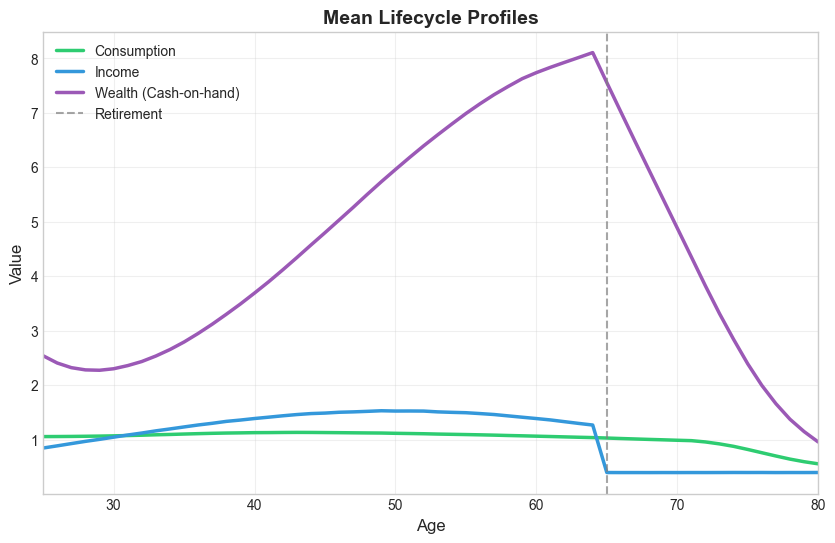

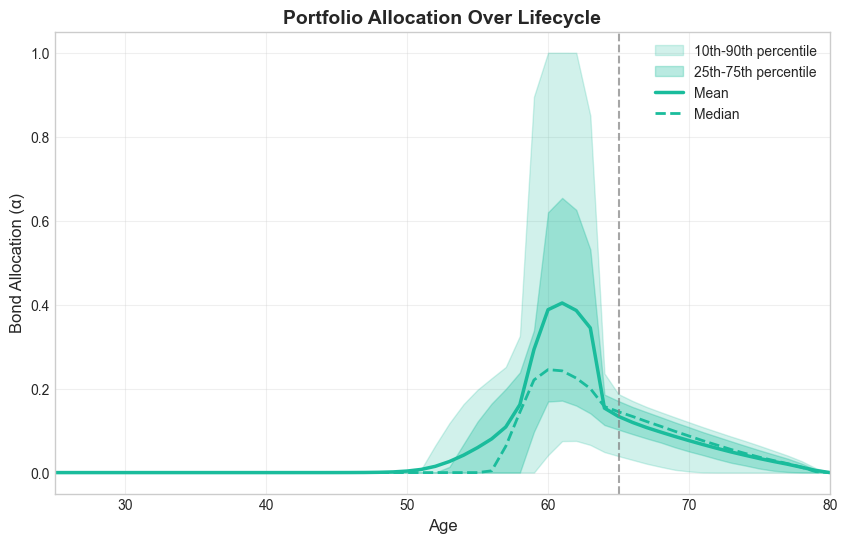

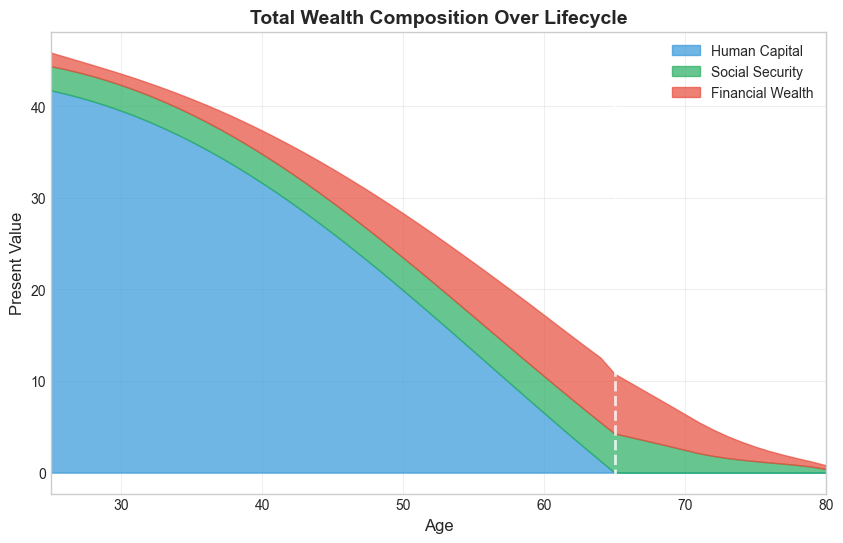

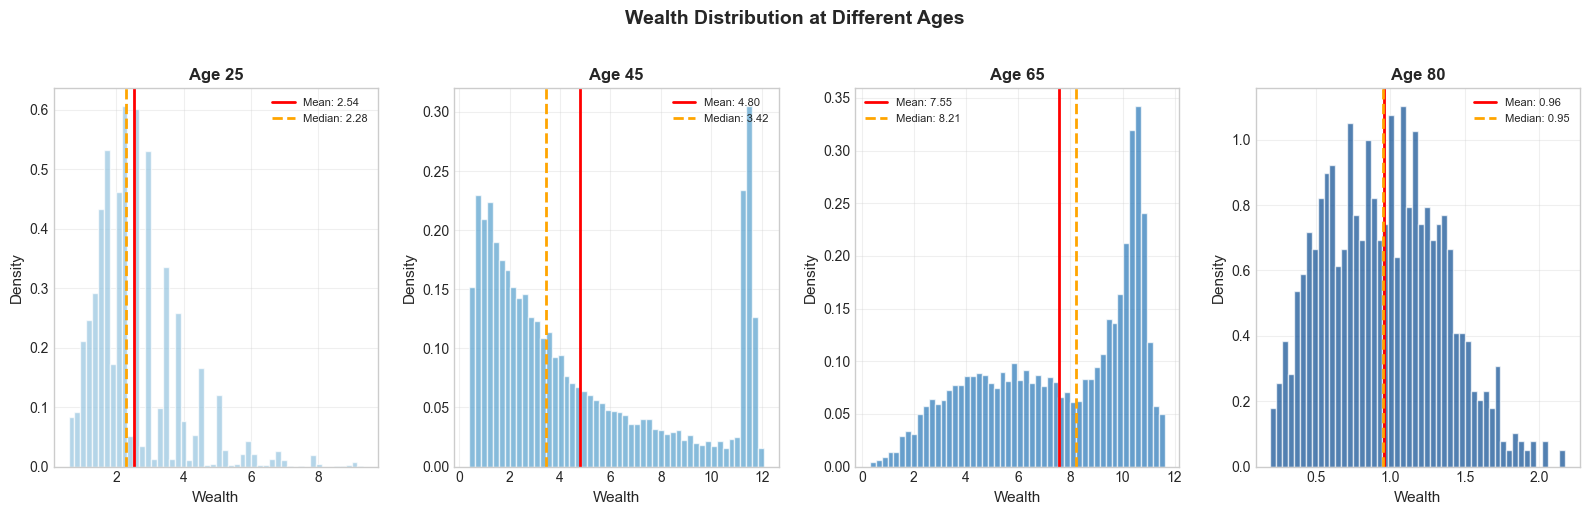

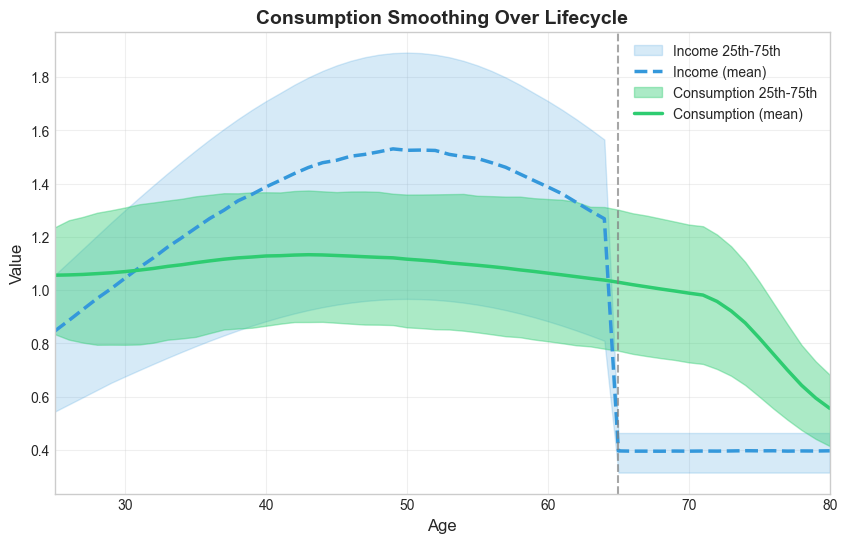

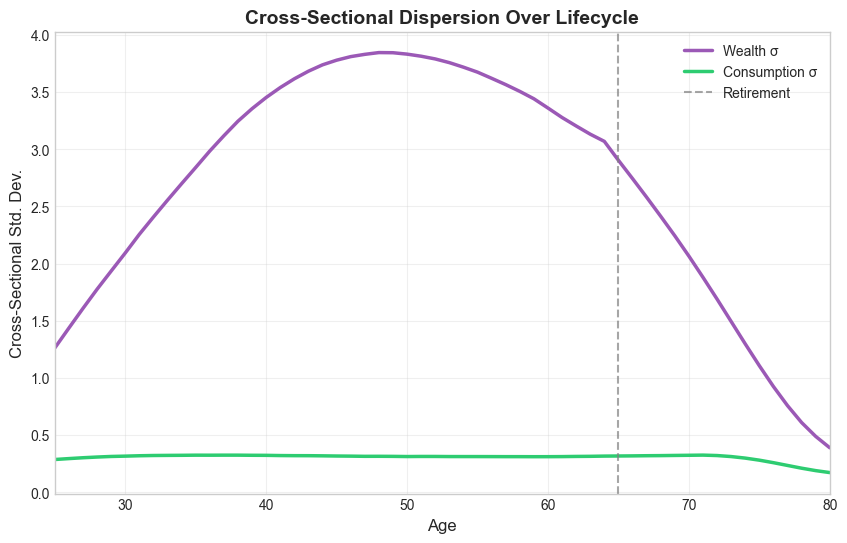

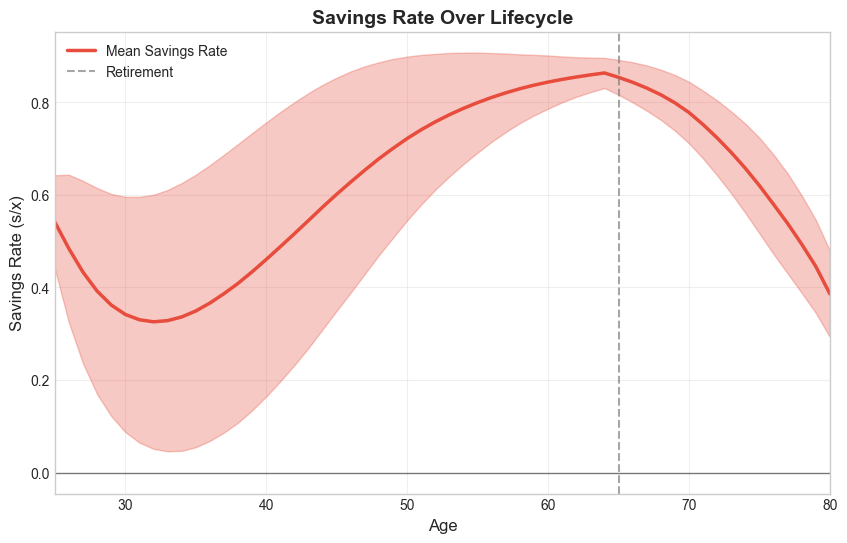

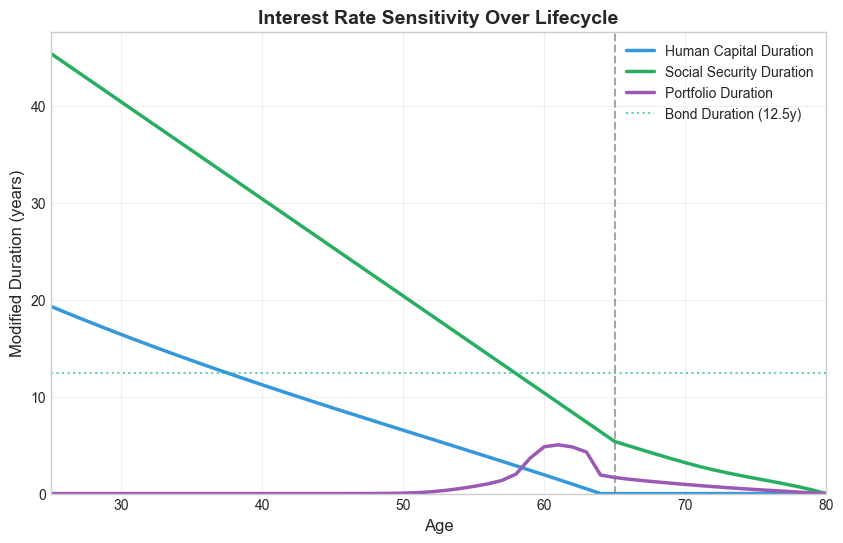


Done! Figures available in 'figures' dictionary.
Keys: ['lifecycle_profiles', 'alpha_fan', 'wealth_composition', 'wealth_distributions', 'consumption_income_fan', 'dispersion', 'savings_rate', 'duration_profile']


In [7]:
"""
LIFECYCLE PORTFOLIO CHOICE MODEL - PLOTTING
==================================================

Complete visualization suite for the lifecycle model results.

Graphs included:
1. Lifecycle profiles - Mean consumption, income, wealth over age
2. Alpha fan chart - Mean bond allocation with percentile bands
3. Human capital + financial wealth - Stacked area composition
4. Alpha by term premium - Comparative statics for different μ_n
5. Wealth distributions - Histograms at ages 25, 45, 65, 80
6. Consumption vs income fan chart - Shows consumption smoothing
7. Cross-sectional dispersion - σ(W) and σ(C) by age
8. Savings rate by age - Mean s/x over lifecycle
9. Interest rate sensitivity - Modified duration of HC, SS, portfolio

"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from typing import Dict, List, Optional, Tuple
import warnings

# Set consistent style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'consumption': '#2ecc71',
    'income': '#3498db', 
    'wealth': '#9b59b6',
    'savings': '#e74c3c',
    'bonds': '#1abc9c',
    'bills': '#f39c12',
    'human_capital': '#3498db',
    'financial_wealth': '#e74c3c',
    'social_security': '#27ae60',
    'portfolio': '#9b59b6'
}


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_cross_sectional_stats(data: np.ndarray, alive: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Compute cross-sectional statistics at each age.
    
    Parameters
    ----------
    data : np.ndarray
        Data array of shape (n_simulations, n_ages)
    alive : np.ndarray
        Boolean array indicating survival, shape (n_simulations, n_ages)
        
    Returns
    -------
    dict
        Dictionary with mean, std, and percentiles (5, 10, 25, 50, 75, 90, 95)
    """
    n_ages = data.shape[1]
    
    stats = {
        'mean': np.zeros(n_ages),
        'std': np.zeros(n_ages),
        'p5': np.zeros(n_ages),
        'p10': np.zeros(n_ages),
        'p25': np.zeros(n_ages),
        'p50': np.zeros(n_ages),
        'p75': np.zeros(n_ages),
        'p90': np.zeros(n_ages),
        'p95': np.zeros(n_ages),
        'n_alive': np.zeros(n_ages)
    }
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        n_alive = np.sum(alive_t)
        stats['n_alive'][t] = n_alive
        
        if n_alive > 0:
            d = data[alive_t, t]
            stats['mean'][t] = np.mean(d)
            stats['std'][t] = np.std(d)
            stats['p5'][t] = np.percentile(d, 5)
            stats['p10'][t] = np.percentile(d, 10)
            stats['p25'][t] = np.percentile(d, 25)
            stats['p50'][t] = np.percentile(d, 50)
            stats['p75'][t] = np.percentile(d, 75)
            stats['p90'][t] = np.percentile(d, 90)
            stats['p95'][t] = np.percentile(d, 95)
    
    return stats


def get_stationary_distribution(Pi: np.ndarray, tol: float = 1e-12, max_iter: int = 10000) -> np.ndarray:
    """Compute stationary distribution of Markov chain."""
    n = Pi.shape[0]
    pi = np.ones(n) / n
    
    for _ in range(max_iter):
        pi_new = pi @ Pi
        if np.max(np.abs(pi_new - pi)) < tol:
            return pi_new
        pi = pi_new
    
    return pi


# =============================================================================
# HUMAN CAPITAL AND DURATION CALCULATIONS
# =============================================================================

def compute_human_capital_and_duration(
    precompute,
    model,
    r_discount: Optional[float] = None
) -> Dict[str, np.ndarray]:
    """
    Compute human capital, social security PV, and their durations at each age.
    
    Parameters
    ----------
    precompute : Precompute
        Precomputed model objects
    model : BondsBillsModel
        Model parameters
    r_discount : float, optional
        Discount rate. If None, uses model.r_bar
        
    Returns
    -------
    dict
        Dictionary with HC, SS, and their durations at each age
    """
    if r_discount is None:
        r_discount = model.r_bar
    
    ages = precompute.ages
    n_ages = len(ages)
    retire_age_idx = model.retire_age - model.start_age
    
    # Get stationary distribution of z for initial expectations
    pi_z = get_stationary_distribution(precompute.Pi_z)
    
    # Storage
    human_capital = np.zeros(n_ages)
    hc_duration = np.zeros(n_ages)
    social_security = np.zeros(n_ages)
    ss_duration = np.zeros(n_ages)
    
    # Expected income at each age (averaged over z and eps)
    expected_income = np.zeros(n_ages)
    for t in range(n_ages):
        if t < retire_age_idx:
            # Working: average over z states and transitory shocks
            inc_by_z = np.sum(precompute.working_income[t, :, :] * precompute.eps_weights, axis=1)
            expected_income[t] = np.dot(pi_z, inc_by_z)
        else:
            # Retired: pension averaged over z states
            expected_income[t] = np.dot(pi_z, precompute.pension_after_tax[t, :])
    
    # Compute cumulative survival probabilities
    cum_survival = np.ones(n_ages)
    for t in range(1, n_ages):
        cum_survival[t] = cum_survival[t-1] * model.survival_probs[t-1]
    
    # For each starting age, compute HC, SS, and durations
    for t in range(n_ages):
        age_t = ages[t]
        
        # -----------------------------------------------------------------
        # Human Capital: PV of future labor income (until retirement)
        # -----------------------------------------------------------------
        hc_pv = 0.0
        hc_dur_numerator = 0.0
        
        for s in range(t, min(retire_age_idx, n_ages)):
            years_ahead = s - t
            discount = np.exp(-r_discount * years_ahead)
            
            # Survival from t to s
            if years_ahead == 0:
                surv = 1.0
            else:
                surv = np.prod(model.survival_probs[t:s])
            
            # Expected income at s given current z distribution
            # For simplicity, use unconditional expectation (stationary z)
            # More accurate: propagate z distribution forward
            exp_income_s = expected_income[s]
            
            pv_cashflow = surv * discount * exp_income_s
            hc_pv += pv_cashflow
            hc_dur_numerator += years_ahead * pv_cashflow
        
        human_capital[t] = hc_pv
        if hc_pv > 1e-10:
            hc_duration[t] = hc_dur_numerator / hc_pv
        
        # -----------------------------------------------------------------
        # Social Security: PV of pension income (after retirement)
        # -----------------------------------------------------------------
        ss_pv = 0.0
        ss_dur_numerator = 0.0
        
        for s in range(max(t, retire_age_idx), n_ages):
            years_ahead = s - t
            discount = np.exp(-r_discount * years_ahead)
            
            # Survival from t to s
            if years_ahead == 0:
                surv = 1.0
            else:
                surv = np.prod(model.survival_probs[t:s])
            
            # Expected pension at s
            # If already retired, z is known (use current z)
            # If not retired, z at retirement is uncertain
            # For simplicity, use unconditional expectation
            exp_pension_s = expected_income[s] if s >= retire_age_idx else 0.0
            
            pv_cashflow = surv * discount * exp_pension_s
            ss_pv += pv_cashflow
            ss_dur_numerator += years_ahead * pv_cashflow
        
        social_security[t] = ss_pv
        if ss_pv > 1e-10:
            ss_duration[t] = ss_dur_numerator / ss_pv
    
    return {
        'ages': ages,
        'human_capital': human_capital,
        'hc_duration': hc_duration,
        'social_security': social_security,
        'ss_duration': ss_duration,
        'expected_income': expected_income
    }


def compute_portfolio_duration(
    sim_data: Dict[str, np.ndarray],
    model
) -> np.ndarray:
    """
    Compute mean portfolio duration at each age.
    
    Portfolio duration = alpha * bond_duration + (1 - alpha) * 0
    
    Parameters
    ----------
    sim_data : dict
        Simulation results
    model : BondsBillsModel
        Model parameters
        
    Returns
    -------
    np.ndarray
        Mean portfolio duration at each age
    """
    # Bond duration
    sigma_n_factor = (1 - model.rho_r**(model.n_bonds - 1)) / (1 - model.rho_r)
    bond_duration = sigma_n_factor  # This is approximately the duration in years
    
    # Mean alpha at each age
    alpha_stats = compute_cross_sectional_stats(sim_data['a'], sim_data['alive'])
    
    # Portfolio duration = alpha * bond_duration
    portfolio_duration = alpha_stats['mean'] * bond_duration
    
    return portfolio_duration


# =============================================================================
# GRAPH 1: LIFECYCLE PROFILES
# =============================================================================

def plot_lifecycle_profiles(
    sim_data: Dict[str, np.ndarray],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot mean consumption, income, and wealth over the lifecycle.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    alive = sim_data['alive']
    
    # Compute means
    c_stats = compute_cross_sectional_stats(sim_data['c'], alive)
    y_stats = compute_cross_sectional_stats(sim_data['income'], alive)
    w_stats = compute_cross_sectional_stats(sim_data['x'], alive)
    
    # Plot
    ax.plot(ages, c_stats['mean'], color=COLORS['consumption'], linewidth=2.5, label='Consumption')
    ax.plot(ages, y_stats['mean'], color=COLORS['income'], linewidth=2.5, label='Income')
    ax.plot(ages, w_stats['mean'], color=COLORS['wealth'], linewidth=2.5, label='Wealth (Cash-on-hand)')
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Retirement')
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title('Mean Lifecycle Profiles', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ages[0], ages[-1])
    
    return fig


# =============================================================================
# GRAPH 2: ALPHA FAN CHART
# =============================================================================

def plot_alpha_fan_chart(
    sim_data: Dict[str, np.ndarray],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot bond allocation with percentile bands.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    alpha_stats = compute_cross_sectional_stats(sim_data['a'], sim_data['alive'])
    
    # Fan chart bands
    ax.fill_between(ages, alpha_stats['p10'], alpha_stats['p90'], 
                    alpha=0.2, color=COLORS['bonds'], label='10th-90th percentile')
    ax.fill_between(ages, alpha_stats['p25'], alpha_stats['p75'], 
                    alpha=0.3, color=COLORS['bonds'], label='25th-75th percentile')
    
    # Mean and median
    ax.plot(ages, alpha_stats['mean'], color=COLORS['bonds'], linewidth=2.5, label='Mean')
    ax.plot(ages, alpha_stats['p50'], color=COLORS['bonds'], linewidth=2, linestyle='--', label='Median')
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Bond Allocation (α)', fontsize=12)
    ax.set_title('Portfolio Allocation Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 3: HUMAN CAPITAL + FINANCIAL WEALTH
# =============================================================================

def plot_wealth_composition(
    sim_data: Dict[str, np.ndarray],
    precompute,
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot stacked area chart of human capital, social security, and financial wealth.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    
    # Compute human capital and social security
    hc_data = compute_human_capital_and_duration(precompute, model)
    
    # Mean financial wealth
    w_stats = compute_cross_sectional_stats(sim_data['s'], sim_data['alive'])
    financial_wealth = w_stats['mean']
    
    # Stacked area chart
    ax.fill_between(ages, 0, hc_data['human_capital'], 
                    alpha=0.7, color=COLORS['human_capital'], label='Human Capital')
    ax.fill_between(ages, hc_data['human_capital'], 
                    hc_data['human_capital'] + hc_data['social_security'],
                    alpha=0.7, color=COLORS['social_security'], label='Social Security')
    ax.fill_between(ages, hc_data['human_capital'] + hc_data['social_security'],
                    hc_data['human_capital'] + hc_data['social_security'] + financial_wealth,
                    alpha=0.7, color=COLORS['financial_wealth'], label='Financial Wealth')
    
    # Retirement line
    ax.axvline(model.retire_age, color='white', linestyle='--', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Present Value', fontsize=12)
    ax.set_title('Total Wealth Composition Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 4: ALPHA BY TERM PREMIUM
# =============================================================================

def compute_term_premium_to_mu_n(term_premium: float, model) -> float:
    """
    Convert term premium to μ_n.
    
    Term premium ≈ μ_n + 0.5 * σ_n²
    So: μ_n = term_premium - 0.5 * σ_n²
    """
    sigma_n = (1 - model.rho_r**(model.n_bonds - 1)) / (1 - model.rho_r) * model.sigma_r
    variance_correction = 0.5 * sigma_n**2
    return term_premium - variance_correction


def plot_alpha_by_term_premium(
    results_by_tp: Dict[float, Dict[str, np.ndarray]],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot mean bond allocation for different term premium levels.
    
    Parameters
    ----------
    results_by_tp : dict
        Dictionary mapping term premium (float) to simulation results dict
    model : BondsBillsModel
        Model parameters
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    # Color map for different term premiums
    term_premiums = sorted(results_by_tp.keys())
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(term_premiums)))
    
    for i, tp in enumerate(term_premiums):
        sim_data = results_by_tp[tp]
        ages = sim_data['ages']
        alpha_stats = compute_cross_sectional_stats(sim_data['a'], sim_data['alive'])
        
        label = f'TP = {tp*100:.1f}%'
        ax.plot(ages, alpha_stats['mean'], color=colors[i], linewidth=2, label=label)
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Mean Bond Allocation (α)', fontsize=12)
    ax.set_title('Bond Allocation by Term Premium', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 5: WEALTH DISTRIBUTIONS
# =============================================================================

def plot_wealth_distributions(
    sim_data: Dict[str, np.ndarray],
    model,
    target_ages: List[int] = [25, 45, 65, 80],
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot wealth distributions at specific ages.
    """
    n_ages_plot = len(target_ages)
    
    if ax is None:
        fig, axes = plt.subplots(1, n_ages_plot, figsize=(4*n_ages_plot, 5))
    else:
        fig = ax.figure
        axes = [ax]
    
    if n_ages_plot == 1:
        axes = [axes]
    
    ages = sim_data['ages']
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, n_ages_plot))
    
    for i, target_age in enumerate(target_ages):
        ax = axes[i]
        
        # Find age index
        age_idx = np.argmin(np.abs(ages - target_age))
        actual_age = ages[age_idx]
        
        # Get wealth for alive households
        alive_t = sim_data['alive'][:, age_idx]
        wealth_t = sim_data['x'][alive_t, age_idx]
        
        # Histogram
        ax.hist(wealth_t, bins=50, density=True, alpha=0.7, color=colors[i], edgecolor='white')
        
        # Add mean and median lines
        mean_w = np.mean(wealth_t)
        median_w = np.median(wealth_t)
        ax.axvline(mean_w, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_w:.2f}')
        ax.axvline(median_w, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_w:.2f}')
        
        ax.set_xlabel('Wealth', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Age {actual_age}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Wealth Distribution at Different Ages', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig


# =============================================================================
# GRAPH 6: CONSUMPTION VS INCOME FAN CHART
# =============================================================================

def plot_consumption_income_fan(
    sim_data: Dict[str, np.ndarray],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot consumption and income fan charts showing consumption smoothing.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    c_stats = compute_cross_sectional_stats(sim_data['c'], sim_data['alive'])
    y_stats = compute_cross_sectional_stats(sim_data['income'], sim_data['alive'])
    
    # Income fan (lighter)
    ax.fill_between(ages, y_stats['p25'], y_stats['p75'], 
                    alpha=0.2, color=COLORS['income'], label='Income 25th-75th')
    ax.plot(ages, y_stats['mean'], color=COLORS['income'], linewidth=2.5, 
            linestyle='--', label='Income (mean)')
    
    # Consumption fan (darker)
    ax.fill_between(ages, c_stats['p25'], c_stats['p75'], 
                    alpha=0.4, color=COLORS['consumption'], label='Consumption 25th-75th')
    ax.plot(ages, c_stats['mean'], color=COLORS['consumption'], linewidth=2.5, 
            label='Consumption (mean)')
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title('Consumption Smoothing Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 7: CROSS-SECTIONAL DISPERSION
# =============================================================================

def plot_cross_sectional_dispersion(
    sim_data: Dict[str, np.ndarray],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot cross-sectional standard deviation of wealth and consumption over lifecycle.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    c_stats = compute_cross_sectional_stats(sim_data['c'], sim_data['alive'])
    w_stats = compute_cross_sectional_stats(sim_data['x'], sim_data['alive'])
    
    # Plot standard deviations
    ax.plot(ages, w_stats['std'], color=COLORS['wealth'], linewidth=2.5, label='Wealth σ')
    ax.plot(ages, c_stats['std'], color=COLORS['consumption'], linewidth=2.5, label='Consumption σ')
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Retirement')
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Cross-Sectional Std. Dev.', fontsize=12)
    ax.set_title('Cross-Sectional Dispersion Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 8: SAVINGS RATE
# =============================================================================

def plot_savings_rate(
    sim_data: Dict[str, np.ndarray],
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot mean savings rate (s/x) over lifecycle.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    n_ages = len(ages)
    alive = sim_data['alive']
    
    # Compute savings rate at each age
    savings_rate_mean = np.zeros(n_ages)
    savings_rate_std = np.zeros(n_ages)
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        if np.sum(alive_t) > 0:
            s_t = sim_data['s'][alive_t, t]
            x_t = sim_data['x'][alive_t, t]
            sr_t = s_t / (x_t + 1e-10)
            savings_rate_mean[t] = np.mean(sr_t)
            savings_rate_std[t] = np.std(sr_t)
    
    # Plot with confidence band
    ax.fill_between(ages, savings_rate_mean - savings_rate_std, 
                    savings_rate_mean + savings_rate_std,
                    alpha=0.3, color=COLORS['savings'])
    ax.plot(ages, savings_rate_mean, color=COLORS['savings'], linewidth=2.5, label='Mean Savings Rate')
    
    # Zero line
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Retirement')
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Savings Rate (s/x)', fontsize=12)
    ax.set_title('Savings Rate Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim(ages[0], ages[-1])
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# GRAPH 9: INTEREST RATE SENSITIVITY (DURATION)
# =============================================================================

def plot_duration_profile(
    sim_data: Dict[str, np.ndarray],
    precompute,
    model,
    ax: Optional[plt.Axes] = None
) -> plt.Figure:
    """
    Plot modified duration of human capital, social security, and portfolio over lifecycle.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure
    
    ages = sim_data['ages']
    
    # Compute human capital and SS durations
    hc_data = compute_human_capital_and_duration(precompute, model)
    
    # Compute portfolio duration
    portfolio_dur = compute_portfolio_duration(sim_data, model)
    
    # Plot durations
    ax.plot(ages, hc_data['hc_duration'], color=COLORS['human_capital'], 
            linewidth=2.5, label='Human Capital Duration')
    ax.plot(ages, hc_data['ss_duration'], color=COLORS['social_security'], 
            linewidth=2.5, label='Social Security Duration')
    ax.plot(ages, portfolio_dur, color=COLORS['portfolio'], 
            linewidth=2.5, label='Portfolio Duration')
    
    # Bond duration reference line
    sigma_n_factor = (1 - model.rho_r**(model.n_bonds - 1)) / (1 - model.rho_r)
    ax.axhline(sigma_n_factor, color=COLORS['bonds'], linestyle=':', linewidth=1.5, 
               alpha=0.7, label=f'Bond Duration ({sigma_n_factor:.1f}y)')
    
    # Retirement line
    ax.axvline(model.retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Modified Duration (years)', fontsize=12)
    ax.set_title('Interest Rate Sensitivity Over Lifecycle', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim(ages[0], ages[-1])
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    
    return fig


# =============================================================================
# MASTER PLOTTING FUNCTION
# =============================================================================

def create_full_plot_suite(
    sim_data: Dict[str, np.ndarray],
    precompute,
    model,
    results_by_tp: Optional[Dict[float, Dict[str, np.ndarray]]] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> Dict[str, plt.Figure]:
    """
    Create all 9 graphs in the plotting suite.
    
    Parameters
    ----------
    sim_data : dict
        Simulation results from simulate_lifecycle()
    precompute : Precompute
        Precomputed model objects
    model : BondsBillsModel
        Model parameters
    results_by_tp : dict, optional
        Dictionary mapping term premium to simulation results for graph 4.
        If None, graph 4 is skipped.
    save_path : str, optional
        Directory to save figures. If None, figures are not saved.
    show : bool
        Whether to display figures
        
    Returns
    -------
    dict
        Dictionary mapping graph names to figure objects
    """
    figures = {}
    
    print("=" * 60)
    print("CREATING PLOT SUITE")
    print("=" * 60)
    
    # Graph 1: Lifecycle profiles
    print("  Creating Graph 1: Lifecycle Profiles...")
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    plot_lifecycle_profiles(sim_data, model, ax1)
    figures['lifecycle_profiles'] = fig1
    if save_path:
        fig1.savefig(f"{save_path}/graph1_lifecycle_profiles.png", dpi=150, bbox_inches='tight')
    
    # Graph 2: Alpha fan chart
    print("  Creating Graph 2: Alpha Fan Chart...")
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    plot_alpha_fan_chart(sim_data, model, ax2)
    figures['alpha_fan'] = fig2
    if save_path:
        fig2.savefig(f"{save_path}/graph2_alpha_fan_chart.png", dpi=150, bbox_inches='tight')
    
    # Graph 3: Wealth composition
    print("  Creating Graph 3: Wealth Composition...")
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    plot_wealth_composition(sim_data, precompute, model, ax3)
    figures['wealth_composition'] = fig3
    if save_path:
        fig3.savefig(f"{save_path}/graph3_wealth_composition.png", dpi=150, bbox_inches='tight')
    
    # Graph 4: Alpha by term premium
    if results_by_tp is not None:
        print("  Creating Graph 4: Alpha by Term Premium...")
        fig4, ax4 = plt.subplots(figsize=(10, 6))
        plot_alpha_by_term_premium(results_by_tp, model, ax4)
        figures['alpha_by_tp'] = fig4
        if save_path:
            fig4.savefig(f"{save_path}/graph4_alpha_by_term_premium.png", dpi=150, bbox_inches='tight')
    else:
        print("  Skipping Graph 4: No term premium results provided")
    
    # Graph 5: Wealth distributions
    print("  Creating Graph 5: Wealth Distributions...")
    fig5 = plot_wealth_distributions(sim_data, model)
    figures['wealth_distributions'] = fig5
    if save_path:
        fig5.savefig(f"{save_path}/graph5_wealth_distributions.png", dpi=150, bbox_inches='tight')
    
    # Graph 6: Consumption vs income fan
    print("  Creating Graph 6: Consumption vs Income Fan...")
    fig6, ax6 = plt.subplots(figsize=(10, 6))
    plot_consumption_income_fan(sim_data, model, ax6)
    figures['consumption_income_fan'] = fig6
    if save_path:
        fig6.savefig(f"{save_path}/graph6_consumption_income_fan.png", dpi=150, bbox_inches='tight')
    
    # Graph 7: Cross-sectional dispersion
    print("  Creating Graph 7: Cross-Sectional Dispersion...")
    fig7, ax7 = plt.subplots(figsize=(10, 6))
    plot_cross_sectional_dispersion(sim_data, model, ax7)
    figures['dispersion'] = fig7
    if save_path:
        fig7.savefig(f"{save_path}/graph7_cross_sectional_dispersion.png", dpi=150, bbox_inches='tight')
    
    # Graph 8: Savings rate
    print("  Creating Graph 8: Savings Rate...")
    fig8, ax8 = plt.subplots(figsize=(10, 6))
    plot_savings_rate(sim_data, model, ax8)
    figures['savings_rate'] = fig8
    if save_path:
        fig8.savefig(f"{save_path}/graph8_savings_rate.png", dpi=150, bbox_inches='tight')
    
    # Graph 9: Duration profile
    print("  Creating Graph 9: Duration Profile...")
    fig9, ax9 = plt.subplots(figsize=(10, 6))
    plot_duration_profile(sim_data, precompute, model, ax9)
    figures['duration_profile'] = fig9
    if save_path:
        fig9.savefig(f"{save_path}/graph9_duration_profile.png", dpi=150, bbox_inches='tight')
    
    print("=" * 60)
    print(f"✓ Created {len(figures)} figures")
    if save_path:
        print(f"✓ Saved to {save_path}/")
    print("=" * 60)
    
    if show:
        plt.show()
    
    return figures


# =============================================================================
#  FUNCTION FOR TERM PREMIUM ANALYSIS
# =============================================================================

def run_term_premium_analysis(
    solve_and_simulate_func,
    model_creator_func,
    precompute_creator_func,
    term_premiums: List[float] = [0.0, 0.005, 0.01, 0.015, 0.02],
    n_simulations: int = 10000,
    verbose: bool = True
) -> Dict[float, Dict[str, np.ndarray]]:
    """
    Run solver and simulation for multiple term premium values.
    
    Parameters
    ----------
    solve_and_simulate_func : callable
        Function that takes (model, precompute, n_simulations) and returns sim_data
    model_creator_func : callable
        Function that takes mu_n and returns model
    precompute_creator_func : callable
        Function that takes model and returns precompute
    term_premiums : list
        List of term premium values to analyze
    n_simulations : int
        Number of simulations per term premium
    verbose : bool
        Print progress
        
    Returns
    -------
    dict
        Dictionary mapping term premium to simulation results
    """
    results = {}
    
    # Get a reference model to compute variance correction
    ref_model = model_creator_func(0.0)
    sigma_n = (1 - ref_model.rho_r**(ref_model.n_bonds - 1)) / (1 - ref_model.rho_r) * ref_model.sigma_r
    variance_correction = 0.5 * sigma_n**2
    
    if verbose:
        print("=" * 60)
        print("TERM PREMIUM ANALYSIS")
        print("=" * 60)
        print(f"  Bond volatility σ_n = {sigma_n:.4f}")
        print(f"  Variance correction = {variance_correction:.4f} ({variance_correction*100:.2f}%)")
        print(f"  Term premiums to analyze: {[f'{tp*100:.1f}%' for tp in term_premiums]}")
        print("=" * 60)
    
    for tp in term_premiums:
        # Convert term premium to mu_n
        mu_n = tp - variance_correction
        
        if verbose:
            print(f"\n  Term Premium = {tp*100:.2f}% (μ_n = {mu_n*100:.2f}%)")
        
        # Create model and precompute with this mu_n
        model = model_creator_func(mu_n)
        precompute = precompute_creator_func(model)
        
        # Solve and simulate
        sim_data = solve_and_simulate_func(model, precompute, n_simulations)
        
        results[tp] = sim_data
        
        if verbose:
            alpha_mean = np.mean(sim_data['a'][sim_data['alive'][:, 0], 0])
            print(f"    Mean α at age 25: {alpha_mean:.3f}")
    
    if verbose:
        print("\n" + "=" * 60)
        print("✓ Term premium analysis complete")
        print("=" * 60)
    
    return results


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

#if __name__ == "__main__":
    print("  - plot_lifecycle_profiles(sim_data, model)")
    print("  - plot_alpha_fan_chart(sim_data, model)")
    print("  - plot_wealth_composition(sim_data, precompute, model)")
    print("  - plot_alpha_by_term_premium(results_by_tp, model)")
    print("  - plot_wealth_distributions(sim_data, model)")
    print("  - plot_consumption_income_fan(sim_data, model)")
    print("  - plot_cross_sectional_dispersion(sim_data, model)")
    print("  - plot_savings_rate(sim_data, model)")
    print("  - plot_duration_profile(sim_data, precompute, model)")
    print("  - create_full_plot_suite(sim_data, precompute, model, ...)")
    print("\nFor term premium analysis:")
    print("  - compute_term_premium_to_mu_n(term_premium, model)")
    print("  - run_term_premium_analysis(...)")
"""
LIFECYCLE MODEL - RUN ALL GRAPHS
=================================

This snippet runs the simulation and creates all 9 graphs.
Assumes you have already run the solver and have:
    - C_policy, A_policy, X_grid from the solver
    - precompute object
    - model object

For Graph 4 (term premium comparison), you need to run the solver
multiple times with different mu_n values.
"""

# =============================================================================
# STEP 1: RUN SIMULATION (assumes solver output is available)
# =============================================================================

import matplotlib.pyplot as plt

# Run simulation with baseline model
print("Running baseline simulation...")
sim_data = simulate_lifecycle(
    C_policy, A_policy, X_grid, precompute, model,
    n_simulations=10000,
    initial_wealth=None,           # Use income multiple
    initial_wealth_multiple=2.0,   # x_0 = 2 * E[Y_0]
    initial_z="stationary",        # Draw from stationary distribution
    initial_r="median",            # Start at median interest rate
    seed=42,
    verbose=True
)

# =============================================================================
# STEP 2: CREATE ALL GRAPHS (except Graph 4)
# =============================================================================

print("\nCreating graphs 1-3, 5-9...")
figures = create_full_plot_suite(
    sim_data=sim_data,
    precompute=precompute,
    model=model,
    results_by_tp=None,  # We'll do Graph 4 separately
    save_path=None,      # Set to a path string to save figures
    show=False           # Set True to display immediately
)

# =============================================================================
# STEP 3: GRAPH 4 - TERM PREMIUM COMPARISON
# =============================================================================
# This requires running the solver multiple times.


# =============================================================================
# STEP 4: DISPLAY OR SAVE
# =============================================================================

# Display all figures
plt.show()

print("\nDone! Figures available in 'figures' dictionary.")
print("Keys:", list(figures.keys()))

TERM PREMIUM ANALYSIS
Bond return volatility (σ_n): 0.1245 (12.45%)
Variance correction (½σ_n²): 0.0078 (0.78%)
Formula: Term Premium = μ_n + ½σ_n²
         μ_n = Term Premium - 0.78%

TERM PREMIUM = 0.0%
  μ_n = -0.775%

SOLVING LIFECYCLE MODEL
Ages: 25 to 80 (56 periods)
Retirement age: 65
State space: 21 × 10 = 210 states per age
Savings grid: 100 points (min=0.000000, max=10.00)
Total state-action space: 1,176,000 points

Solving terminal age 80...

Backward induction:
  Age  79 (RETIREMENT) -   0.02s elapsed
  Age  75 (RETIREMENT) -   0.13s elapsed
  Age  70 (RETIREMENT) -   0.23s elapsed
  Age  65 (RETIREMENT) -   0.30s elapsed
  Age  60 (WORKING   ) -   0.99s elapsed
  Age  55 (WORKING   ) -   1.76s elapsed
  Age  50 (WORKING   ) -   2.27s elapsed
  Age  45 (WORKING   ) -   2.67s elapsed
  Age  40 (WORKING   ) -   3.05s elapsed
  Age  35 (WORKING   ) -   3.39s elapsed
  Age  30 (WORKING   ) -   3.77s elapsed
  Age  25 (WORKING   ) -   4.10s elapsed

✅ LIFECYCLE SOLVED in 4.10 se

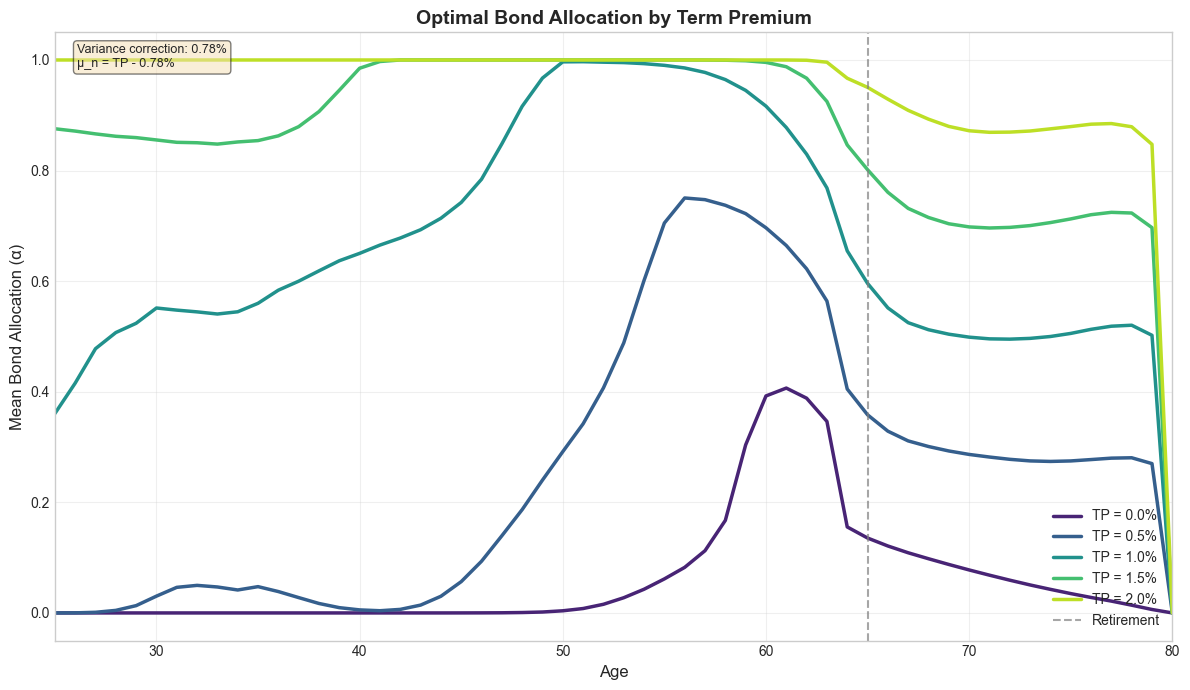


✅ Results stored in 'results_by_tp' dictionary
   Use with: plot_alpha_by_term_premium(results_by_tp, model, ax)


In [9]:
"""
TERM PREMIUM ANALYSIS - GRAPH 4
================================

This cell runs the solver and simulation for multiple term premium values,
then plots the mean bond allocation over the lifecycle for each.

Term premiums analyzed: 0%, 0.5%, 1%, 1.5%, 2%

Note: This will take a few minutes as it runs the solver 5 times.
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# HELPER FUNCTION: Create model and precompute for a given mu_n
# =============================================================================

def create_model_and_precompute(mu_n_value):
    """Create model and precompute for a specific mu_n value."""
    
    model_tp = BondsBillsModel(
        u=lambda c: (c**(1-gamma))/(1-gamma),
        u_prime=lambda c: c**(-gamma),
        u_prime_inv=lambda mu: mu**(-1/gamma),
        beta=beta, gamma=gamma,
        theta=theta, kappa=kappa,
        start_age=start_age, retire_age=retire_age, terminal_age=terminal_age,
        survival_probs=survival_probs,
        phi1=phi1, phi2=phi2,
        rho=rho, pz=pz, mu_eta1=mu_eta1, sigma_eta1=sigma_eta1,
        mu_eta2=mu_eta2, sigma_eta2=sigma_eta2,
        pe=pe, mu_eps1=mu_eps1, sigma_eps1=sigma_eps1,
        mu_eps2=mu_eps2, sigma_eps2=sigma_eps2,
        r_bar=r_bar, rho_r=rho_r, sigma_r=sigma_r,
        n_bonds=n_bonds, 
        mu_n=mu_n_value,
    )
    
    # Suppress debug output for cleaner logs
    precompute_tp = Precompute(model_tp, n_z=n_z, n_r=n_r, n_eps_nodes=n_eps_nodes)
    
    return model_tp, precompute_tp


# =============================================================================
# COMPUTE VARIANCE CORRECTION
# =============================================================================

sigma_n = (1 - rho_r**(n_bonds - 1)) / (1 - rho_r) * sigma_r
var_correction = 0.5 * sigma_n**2

print("=" * 70)
print("TERM PREMIUM ANALYSIS")
print("=" * 70)
print(f"Bond return volatility (σ_n): {sigma_n:.4f} ({sigma_n*100:.2f}%)")
print(f"Variance correction (½σ_n²): {var_correction:.4f} ({var_correction*100:.2f}%)")
print(f"Formula: Term Premium = μ_n + ½σ_n²")
print(f"         μ_n = Term Premium - {var_correction*100:.2f}%")
print("=" * 70)


# =============================================================================
# RUN SOLVER AND SIMULATION FOR EACH TERM PREMIUM
# =============================================================================

# Term premiums: 0%, 0.5%, 1%, 1.5%, 2%
term_premiums = [0.0, 0.005, 0.01, 0.015, 0.02]
results_by_tp = {}

import time
total_start = time.time()

for tp in term_premiums:
    print(f"\n{'='*60}")
    print(f"TERM PREMIUM = {tp*100:.1f}%")
    print(f"{'='*60}")
    
    # Convert term premium to mu_n
    mu_n_val = tp - var_correction
    print(f"  μ_n = {mu_n_val*100:.3f}%")
    
    # Create model and precompute with this mu_n
    model_tp, precompute_tp = create_model_and_precompute(mu_n_val)
    
    # Solve
    C_tp, A_tp, X_tp = run_lifecycle_solver(
        model_tp, precompute_tp, 
        n_s_points=100, 
        apply_sorting=True
    )
    
    # Simulate
    sim_tp = simulate_lifecycle(
        C_tp, A_tp, X_tp, precompute_tp, model_tp,
        n_simulations=10000,
        initial_z='stationary',
        initial_r='median',
        seed=42,
        verbose=True
    )
    
    # Store results
    results_by_tp[tp] = sim_tp
    
    # Quick summary
    mean_alpha_25 = np.mean(sim_tp['a'][sim_tp['alive'][:, 0], 0])
    mean_alpha_45 = np.mean(sim_tp['a'][sim_tp['alive'][:, 20], 20])
    mean_alpha_65 = np.mean(sim_tp['a'][sim_tp['alive'][:, 40], 40])
    print(f"\n  Mean α at age 25: {mean_alpha_25:.3f}")
    print(f"  Mean α at age 45: {mean_alpha_45:.3f}")
    print(f"  Mean α at age 65: {mean_alpha_65:.3f}")

total_elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"TERM PREMIUM ANALYSIS COMPLETE")
print(f"Total time: {total_elapsed:.1f} seconds ({total_elapsed/60:.1f} minutes)")
print(f"{'='*70}")


# =============================================================================
# PLOT GRAPH 4: ALPHA BY TERM PREMIUM
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Color map
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(term_premiums)))

for i, tp in enumerate(term_premiums):
    sim = results_by_tp[tp]
    ages = sim['ages']
    n_ages = len(ages)
    
    # Compute mean alpha at each age (conditional on being alive)
    mean_alpha = np.zeros(n_ages)
    for t in range(n_ages):
        alive_t = sim['alive'][:, t]
        if np.sum(alive_t) > 0:
            mean_alpha[t] = np.mean(sim['a'][alive_t, t])
    
    label = f'TP = {tp*100:.1f}%'
    ax.plot(ages, mean_alpha, color=colors[i], linewidth=2.5, label=label)

# Retirement line
ax.axvline(retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Retirement')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Mean Bond Allocation (α)', fontsize=12)
ax.set_title('Optimal Bond Allocation by Term Premium', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(25, 80)
ax.grid(True, alpha=0.3)

# Add text box with variance correction info
textstr = f'Variance correction: {var_correction*100:.2f}%\nμ_n = TP - {var_correction*100:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Store for use in create_full_plot_suite
print("\n✅ Results stored in 'results_by_tp' dictionary")
print("   Use with: plot_alpha_by_term_premium(results_by_tp, model, ax)")

DURATION MATCHING ANALYSIS
Bond duration: 12.5 years
Variance correction: 0.78%

TERM PREMIUM = 0.0%
  μ_n = -0.775%
  Creating model...
  Solving...

SOLVING LIFECYCLE MODEL
Ages: 25 to 80 (56 periods)
Retirement age: 65
State space: 21 × 10 = 210 states per age
Savings grid: 100 points (min=0.000000, max=10.00)
Total state-action space: 1,176,000 points

Solving terminal age 80...

Backward induction:
  Age  79 (RETIREMENT) -   0.02s elapsed
  Age  75 (RETIREMENT) -   0.13s elapsed
  Age  70 (RETIREMENT) -   0.23s elapsed
  Age  65 (RETIREMENT) -   0.30s elapsed
  Age  60 (WORKING   ) -   0.97s elapsed
  Age  55 (WORKING   ) -   1.75s elapsed
  Age  50 (WORKING   ) -   2.27s elapsed
  Age  45 (WORKING   ) -   2.69s elapsed
  Age  40 (WORKING   ) -   3.06s elapsed
  Age  35 (WORKING   ) -   3.43s elapsed
  Age  30 (WORKING   ) -   3.78s elapsed
  Age  25 (WORKING   ) -   4.13s elapsed

✅ LIFECYCLE SOLVED in 4.13 seconds

  Simulating with fixed initial state...
SIMULATING LIFECYCLE PA

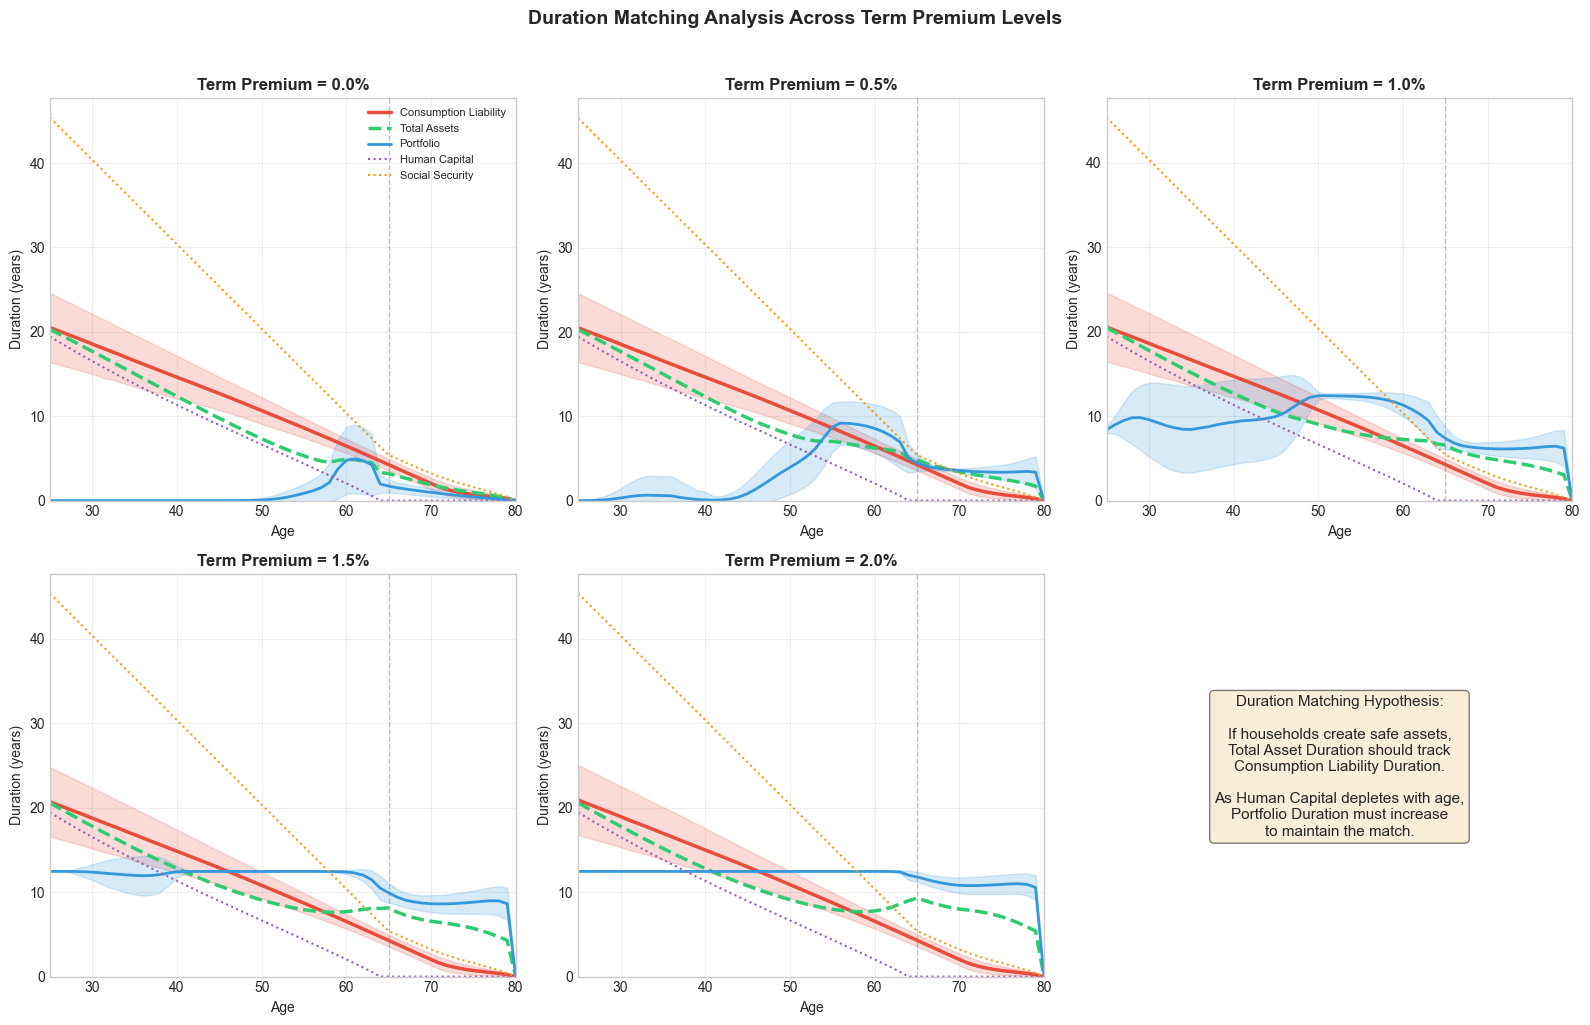

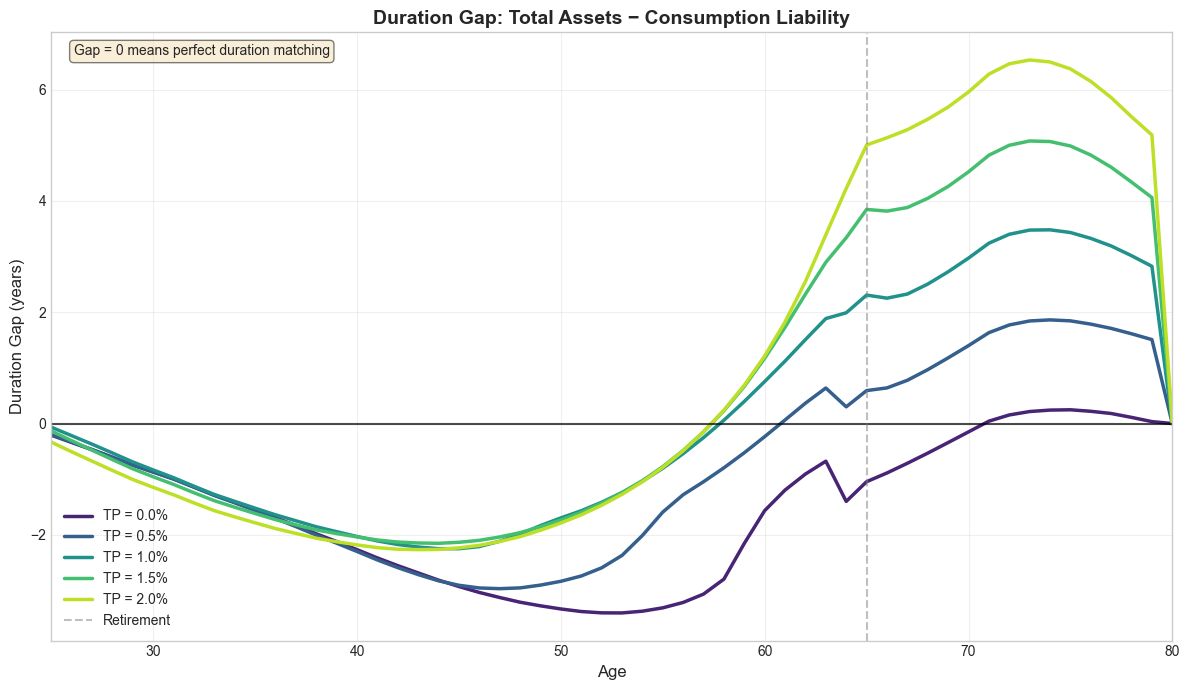


✅ Duration matching analysis complete!
   Results stored in 'duration_results_by_tp' dictionary


In [10]:
"""
GRAPH 10: DURATION MATCHING ANALYSIS
=====================================

This cell tests the hypothesis that households create safe assets by mixing 
bonds and bills to match the duration of their consumption liabilities.

For each term premium level (0%, 0.5%, 1%, 1.5%, 2%):
- Start all households from the SAME initial state (median z, median r)
- Simulate forward, computing at each age:
  - Consumption liability duration: PV-weighted average time to future consumption
  - Asset durations: Human Capital, Social Security, Financial Portfolio
  - Total asset duration: value-weighted combination
- Plot mean durations with std bands (Monte Carlo estimates)

If households are duration-matching:
  Total Asset Duration ≈ Consumption Liability Duration

Expected runtime: ~5-10 minutes (5 solves + 5 simulations + duration calculations)
"""

import numpy as np
import matplotlib.pyplot as plt
import time

# =============================================================================
# DURATION CALCULATION FUNCTIONS
# =============================================================================

def compute_consumption_liability_duration(sim_data, model, r_discount):
    """
    Compute consumption liability duration for each household at each age.
    
    Duration at age t = PV-weighted average time to future consumption
    """
    consumption = sim_data['c']
    alive = sim_data['alive']
    n_sims, n_ages = consumption.shape
    
    durations = np.full((n_sims, n_ages), np.nan)
    
    # Cumulative survival from t to s
    cum_surv = np.ones((n_ages, n_ages))
    for t in range(n_ages):
        for s in range(t + 1, n_ages):
            cum_surv[t, s] = cum_surv[t, s-1] * model.survival_probs[s-1]
    
    for i in range(n_sims):
        for t in range(n_ages):
            if not alive[i, t]:
                continue
            
            pv_sum = 0.0
            pv_time_sum = 0.0
            
            for s in range(t, n_ages):
                if not alive[i, s]:
                    break
                
                years_ahead = s - t
                discount = np.exp(-r_discount * years_ahead)
                surv = cum_surv[t, s]
                pv_c = surv * discount * consumption[i, s]
                
                pv_sum += pv_c
                pv_time_sum += years_ahead * pv_c
            
            if pv_sum > 1e-10:
                durations[i, t] = pv_time_sum / pv_sum
    
    # Statistics
    duration_mean = np.zeros(n_ages)
    duration_std = np.zeros(n_ages)
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        valid = alive_t & ~np.isnan(durations[:, t])
        if np.sum(valid) > 0:
            duration_mean[t] = np.mean(durations[valid, t])
            duration_std[t] = np.std(durations[valid, t])
    
    return duration_mean, duration_std


def compute_human_capital_duration(sim_data, precompute, model, r_discount):
    """
    Compute human capital duration and value for each household.
    HC = PV of future labor income until retirement.
    """
    income = sim_data['income']
    alive = sim_data['alive']
    n_sims, n_ages = income.shape
    
    retire_age_idx = model.retire_age - model.start_age
    
    cum_surv = np.ones((n_ages, n_ages))
    for t in range(n_ages):
        for s in range(t + 1, n_ages):
            cum_surv[t, s] = cum_surv[t, s-1] * model.survival_probs[s-1]
    
    hc_values = np.full((n_sims, n_ages), np.nan)
    hc_durations = np.full((n_sims, n_ages), np.nan)
    
    for i in range(n_sims):
        for t in range(n_ages):
            if not alive[i, t]:
                continue
            
            pv_sum = 0.0
            pv_time_sum = 0.0
            
            for s in range(t, min(retire_age_idx, n_ages)):
                years_ahead = s - t
                discount = np.exp(-r_discount * years_ahead)
                surv = cum_surv[t, s]
                
                # Use average income for future periods
                if s == t:
                    exp_income = income[i, s]
                else:
                    exp_income = np.mean(precompute.working_income[s, :, :])
                
                pv_inc = surv * discount * exp_income
                pv_sum += pv_inc
                pv_time_sum += years_ahead * pv_inc
            
            hc_values[i, t] = pv_sum
            hc_durations[i, t] = pv_time_sum / pv_sum if pv_sum > 1e-10 else 0.0
    
    # Statistics
    hc_dur_mean = np.zeros(n_ages)
    hc_dur_std = np.zeros(n_ages)
    hc_val_mean = np.zeros(n_ages)
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        valid = alive_t & ~np.isnan(hc_durations[:, t])
        if np.sum(valid) > 0:
            hc_dur_mean[t] = np.mean(hc_durations[valid, t])
            hc_dur_std[t] = np.std(hc_durations[valid, t])
            hc_val_mean[t] = np.mean(hc_values[valid, t])
    
    return hc_dur_mean, hc_dur_std, hc_val_mean


def compute_social_security_duration(sim_data, precompute, model, r_discount):
    """
    Compute social security (pension) duration and value.
    SS = PV of future pension from retirement to death.
    """
    income = sim_data['income']
    alive = sim_data['alive']
    n_sims, n_ages = income.shape
    
    retire_age_idx = model.retire_age - model.start_age
    
    cum_surv = np.ones((n_ages, n_ages))
    for t in range(n_ages):
        for s in range(t + 1, n_ages):
            cum_surv[t, s] = cum_surv[t, s-1] * model.survival_probs[s-1]
    
    ss_values = np.full((n_sims, n_ages), np.nan)
    ss_durations = np.full((n_sims, n_ages), np.nan)
    
    for i in range(n_sims):
        for t in range(n_ages):
            if not alive[i, t]:
                continue
            
            pv_sum = 0.0
            pv_time_sum = 0.0
            
            for s in range(max(t, retire_age_idx), n_ages):
                years_ahead = s - t
                discount = np.exp(-r_discount * years_ahead)
                surv = cum_surv[t, s]
                
                if s == t and t >= retire_age_idx:
                    exp_pension = income[i, s]
                else:
                    exp_pension = np.mean(precompute.pension_after_tax[s, :])
                
                pv_pen = surv * discount * exp_pension
                pv_sum += pv_pen
                pv_time_sum += years_ahead * pv_pen
            
            ss_values[i, t] = pv_sum
            ss_durations[i, t] = pv_time_sum / pv_sum if pv_sum > 1e-10 else 0.0
    
    # Statistics
    ss_dur_mean = np.zeros(n_ages)
    ss_dur_std = np.zeros(n_ages)
    ss_val_mean = np.zeros(n_ages)
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        valid = alive_t & ~np.isnan(ss_durations[:, t])
        if np.sum(valid) > 0:
            ss_dur_mean[t] = np.mean(ss_durations[valid, t])
            ss_dur_std[t] = np.std(ss_durations[valid, t])
            ss_val_mean[t] = np.mean(ss_values[valid, t])
    
    return ss_dur_mean, ss_dur_std, ss_val_mean


def compute_portfolio_duration(sim_data, model):
    """
    Compute financial portfolio duration and value.
    Portfolio duration = α * D_bond (bills have zero duration)
    """
    alpha = sim_data['a']
    savings = sim_data['s']
    alive = sim_data['alive']
    n_sims, n_ages = alpha.shape
    
    # Bond duration
    bond_duration = (1 - model.rho_r**(model.n_bonds - 1)) / (1 - model.rho_r)
    
    port_durations = alpha * bond_duration
    
    # Statistics
    port_dur_mean = np.zeros(n_ages)
    port_dur_std = np.zeros(n_ages)
    port_val_mean = np.zeros(n_ages)
    
    for t in range(n_ages):
        alive_t = alive[:, t]
        if np.sum(alive_t) > 0:
            port_dur_mean[t] = np.mean(port_durations[alive_t, t])
            port_dur_std[t] = np.std(port_durations[alive_t, t])
            port_val_mean[t] = np.mean(savings[alive_t, t])
    
    return port_dur_mean, port_dur_std, port_val_mean


def compute_all_durations(sim_data, precompute, model):
    """Compute all duration measures."""
    r_discount = model.r_bar
    ages = sim_data['ages']
    
    print("    Computing consumption liability duration...")
    cons_dur_mean, cons_dur_std = compute_consumption_liability_duration(
        sim_data, model, r_discount
    )
    
    print("    Computing human capital duration...")
    hc_dur_mean, hc_dur_std, hc_val_mean = compute_human_capital_duration(
        sim_data, precompute, model, r_discount
    )
    
    print("    Computing social security duration...")
    ss_dur_mean, ss_dur_std, ss_val_mean = compute_social_security_duration(
        sim_data, precompute, model, r_discount
    )
    
    print("    Computing portfolio duration...")
    port_dur_mean, port_dur_std, port_val_mean = compute_portfolio_duration(
        sim_data, model
    )
    
    # Total asset duration (value-weighted)
    total_val = hc_val_mean + ss_val_mean + port_val_mean
    total_val = np.maximum(total_val, 1e-10)
    total_asset_dur = (hc_val_mean * hc_dur_mean + 
                       ss_val_mean * ss_dur_mean + 
                       port_val_mean * port_dur_mean) / total_val
    
    return {
        'ages': ages,
        'consumption_duration_mean': cons_dur_mean,
        'consumption_duration_std': cons_dur_std,
        'hc_duration_mean': hc_dur_mean,
        'hc_duration_std': hc_dur_std,
        'hc_value_mean': hc_val_mean,
        'ss_duration_mean': ss_dur_mean,
        'ss_duration_std': ss_dur_std,
        'ss_value_mean': ss_val_mean,
        'portfolio_duration_mean': port_dur_mean,
        'portfolio_duration_std': port_dur_std,
        'portfolio_value_mean': port_val_mean,
        'total_asset_duration': total_asset_dur,
    }


# =============================================================================
# VARIANCE CORRECTION
# =============================================================================

sigma_n = (1 - rho_r**(n_bonds - 1)) / (1 - rho_r) * sigma_r
var_correction = 0.5 * sigma_n**2

print("=" * 70)
print("DURATION MATCHING ANALYSIS")
print("=" * 70)
print(f"Bond duration: {(1 - rho_r**(n_bonds - 1)) / (1 - rho_r):.1f} years")
print(f"Variance correction: {var_correction*100:.2f}%")
print("=" * 70)


# =============================================================================
# RUN ANALYSIS FOR EACH TERM PREMIUM
# =============================================================================

term_premiums = [0.0, 0.005, 0.01, 0.015, 0.02]
results_by_tp = {}
duration_results_by_tp = {}

total_start = time.time()

for tp in term_premiums:
    print(f"\n{'='*60}")
    print(f"TERM PREMIUM = {tp*100:.1f}%")
    print(f"{'='*60}")
    
    mu_n_val = tp - var_correction
    print(f"  μ_n = {mu_n_val*100:.3f}%")
    
    # Create model and precompute
    print("  Creating model...")
    model_tp, precompute_tp = create_model_and_precompute(mu_n_val)
    
    # Solve
    print("  Solving...")
    C_tp, A_tp, X_tp = run_lifecycle_solver(
        model_tp, precompute_tp, n_s_points=100, apply_sorting=True
    )
    
    # Simulate with FIXED initial state
    print("  Simulating with fixed initial state...")
    sim_tp = simulate_lifecycle(
        C_tp, A_tp, X_tp, precompute_tp, model_tp,
        n_simulations=10000,
        initial_wealth_multiple=2.0,
        initial_z="median",   # Fixed: all start at median z
        initial_r="median",   # Fixed: all start at median r
        seed=42,
        verbose=True
    )
    
    results_by_tp[tp] = sim_tp
    
    # Compute durations
    print("  Computing durations...")
    dur_tp = compute_all_durations(sim_tp, precompute_tp, model_tp)
    duration_results_by_tp[tp] = dur_tp

total_elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"ANALYSIS COMPLETE - Total time: {total_elapsed/60:.1f} minutes")
print(f"{'='*70}")


# =============================================================================
# PLOT 1: DURATION MATCHING (5 SUBPLOTS)
# =============================================================================

fig1, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

color_consumption = '#e74c3c'
color_total_asset = '#2ecc71'
color_portfolio = '#3498db'
color_hc = '#9b59b6'
color_ss = '#f39c12'

for i, tp in enumerate(term_premiums):
    ax = axes[i]
    dur = duration_results_by_tp[tp]
    ages = dur['ages']
    
    # Consumption liability with std band
    ax.fill_between(ages,
        dur['consumption_duration_mean'] - dur['consumption_duration_std'],
        dur['consumption_duration_mean'] + dur['consumption_duration_std'],
        alpha=0.2, color=color_consumption)
    ax.plot(ages, dur['consumption_duration_mean'], 
            color=color_consumption, linewidth=2.5, label='Consumption Liability')
    
    # Total asset duration
    ax.plot(ages, dur['total_asset_duration'],
            color=color_total_asset, linewidth=2.5, linestyle='--', label='Total Assets')
    
    # Portfolio duration with std band
    ax.fill_between(ages,
        dur['portfolio_duration_mean'] - dur['portfolio_duration_std'],
        dur['portfolio_duration_mean'] + dur['portfolio_duration_std'],
        alpha=0.2, color=color_portfolio)
    ax.plot(ages, dur['portfolio_duration_mean'],
            color=color_portfolio, linewidth=2, label='Portfolio')
    
    # HC and SS durations
    ax.plot(ages, dur['hc_duration_mean'],
            color=color_hc, linewidth=1.5, linestyle=':', label='Human Capital')
    ax.plot(ages, dur['ss_duration_mean'],
            color=color_ss, linewidth=1.5, linestyle=':', label='Social Security')
    
    ax.axvline(retire_age, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Age', fontsize=10)
    ax.set_ylabel('Duration (years)', fontsize=10)
    ax.set_title(f'Term Premium = {tp*100:.1f}%', fontsize=12, fontweight='bold')
    ax.set_xlim(ages[0], ages[-1])
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Explanation in 6th panel
axes[5].axis('off')
axes[5].text(0.5, 0.7, 
    'Duration Matching Hypothesis:\n\n'
    'If households create safe assets,\n'
    'Total Asset Duration should track\n'
    'Consumption Liability Duration.\n\n'
    'As Human Capital depletes with age,\n'
    'Portfolio Duration must increase\n'
    'to maintain the match.',
    transform=axes[5].transAxes, fontsize=11, 
    verticalalignment='top', horizontalalignment='center',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig1.suptitle('Duration Matching Analysis Across Term Premium Levels', 
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# =============================================================================
# PLOT 2: DURATION GAP
# =============================================================================

fig2, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(term_premiums)))

for i, tp in enumerate(term_premiums):
    dur = duration_results_by_tp[tp]
    ages = dur['ages']
    gap = dur['total_asset_duration'] - dur['consumption_duration_mean']
    ax.plot(ages, gap, color=colors[i], linewidth=2.5, label=f'TP = {tp*100:.1f}%')

ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(retire_age, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Retirement')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Duration Gap (years)', fontsize=12)
ax.set_title('Duration Gap: Total Assets − Consumption Liability', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.set_xlim(ages[0], ages[-1])
ax.grid(True, alpha=0.3)

ax.text(0.02, 0.98, 'Gap = 0 means perfect duration matching',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✅ Duration matching analysis complete!")
print("   Results stored in 'duration_results_by_tp' dictionary")